# DeepWeeds — Lab Day 2: kết quả thực nghiệm và chạy lại trên Colab

**Notebook đã có output từ nghiên cứu local thật**: GTX1650, profile hour, 128px,
1epoch khảo sát và 12epoch chung kết, 3 seed. Log/CSV/PNG gốc nằm trong bài nộp.
Các cell ở chế độ mặc định chỉ đọc và hiển thị kết quả đã kiểm tra hash; không train/test lại.
Số thứ tự thực thi trong bản này là lần chạy các cell hiển thị, không phải một phiên train mới.

- Xem ngay các bảng, đồ thị/ảnh và log bên dưới trên GitHub hoặc Colab.
- Muốn train lại: đặt **VIEW_SAVED_RESULTS=False**, chọn GPU, dùng SESSION mới và Run all.
- PROFILE=hour: 128px, 1epoch khảo sát; FINAL_EPOCHS=12 như lượt local. Batch/AMP chọn
  theo GPU được cấp, nên thời gian và kết quả có thể khác máy local.
- Temperature và lựa chọn chỉ trên val; test cuối cùng một lần mỗi cấu hình/seed.

[Báo cáo hoàn thiện](https://github.com/meth04/K4-DAY02-NguyenVanThan-02859/blob/main/submissions/02859_nguyen_van_than/report.md)
· [Bài nộp](https://github.com/meth04/K4-DAY02-NguyenVanThan-02859/tree/main/submissions/02859_nguyen_van_than)


## 1. Cấu hình — thường chỉ cần giữ mặc định


In [1]:
VIEW_SAVED_RESULTS = True      # True: xem kết quả đã lưu; False: train lại trên Colab
PROFILE = "hour"               # hour | fast | full | smoke
FINAL_EPOCHS = 12               # Lượt local đã train 12 epoch chung kết
SAVE_TO_DRIVE = True
SESSION = "deepweeds_day2_reproduction"  # SESSION mới khi train nghiên cứu mới
ROOT = f"/content/{SESSION}_{PROFILE}"
print("Chế độ:", "xem kết quả đã lưu, không train/test lại" if VIEW_SAVED_RESULTS else "train mới trên Colab")
print("Profile chạy lại:", PROFILE, "| final epochs:", FINAL_EPOCHS)


Chế độ: xem kết quả đã lưu, không train/test lại
Profile chạy lại: hour | final epochs: 12


## 2. Cài thư viện và kiểm tra GPU


In [2]:
import os, sys, json
from pathlib import Path
if VIEW_SAVED_RESULTS:
    import importlib.util, subprocess
    if importlib.util.find_spec("openpyxl") is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "openpyxl"], check=True)
    import pandas as pd
    from IPython.display import display
    print("Chế độ xem kết quả: không cần GPU. Phần cứng train thật được hiển thị ở cell khởi tạo.")
else:
    import sys, os, json, platform, subprocess, time
    from pathlib import Path
    # Compatibility with cuDNN engine selection on small/older GPUs; set before torch import.
    os.environ.setdefault("TORCH_CUDNN_V8_API_DISABLED", "1")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "timm==1.0.30", "openpyxl", "scikit-learn"], check=True)
    import torch, torchvision, timm, numpy as np, pandas as pd
    assert torch.cuda.is_available(), "Chọn Runtime > Change runtime type > GPU trước khi train."
    torch.backends.cudnn.benchmark = False
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("GPU:", torch.cuda.get_device_name(0))
    print("torch:", torch.__version__, "torchvision:", torchvision.__version__, "timm:", timm.__version__)
    print("Profile:", PROFILE, "| RAM workers:", min(4, os.cpu_count() or 2))


Chế độ xem kết quả: không cần GPU. Phần cứng train thật được hiển thị ở cell khởi tạo.


## 3. Tải code từ GitHub

Tải một lần từ commit đã chốt; lần chạy sau dùng lại file tải sẵn.
Code Python nằm trong thư mục `code/`, có thể mở để xem từng module.


In [3]:
from urllib.request import urlretrieve
from zipfile import ZipFile
if VIEW_SAVED_RESULTS:
    RESULTS_COMMIT = "6a83534f132723e36afbcc3caa75098f21180df4"
    local_results = os.environ.get("DEEPWEEDS_SAVED_RESULTS_DIR")
    if local_results:  # Chỉ dành cho xuất notebook offline trên máy có artifact
        saved_root = Path(local_results)
        helper = Path(os.environ["DEEPWEEDS_RESULTS_HELPER"])
    else:
        cache = Path("/content" if Path("/content").exists() else ".") / f"deepweeds_saved_{RESULTS_COMMIT[:7]}"
        cache.mkdir(parents=True, exist_ok=True)
        saved_root = cache / "submission"
        helper = cache / "notebook_results.py"
        if not (saved_root / "manifest.json").exists() or not helper.exists():
            archive_path = cache / "source.zip"
            urlretrieve(f"https://codeload.github.com/meth04/K4-DAY02-NguyenVanThan-02859/zip/{RESULTS_COMMIT}", archive_path)
            with ZipFile(archive_path) as archive:
                for member in archive.namelist():
                    relative = member.partition("/")[2]
                    prefix = "submissions/02859_nguyen_van_than/"
                    if relative.startswith(prefix) and not member.endswith("/"):
                        target = saved_root / relative[len(prefix):]
                        target.parent.mkdir(parents=True, exist_ok=True)
                        target.write_bytes(archive.read(member))
                    elif relative == "code/notebook_results.py":
                        helper.write_bytes(archive.read(member))
    sys.path.insert(0, str(helper.parent))
    from notebook_results import SavedResults
    results = SavedResults(saved_root)
    results.show("source")
    results.show("environment")
else:
    from urllib.request import urlretrieve
    from zipfile import ZipFile

    REPO = "meth04/K4-DAY02-NguyenVanThan-02859"
    SOURCE_COMMIT = "6a83534f132723e36afbcc3caa75098f21180df4"
    archive_path = Path(ROOT).parent / f"deepweeds_source_{SOURCE_COMMIT}.zip"
    if not archive_path.exists():
        temporary = archive_path.with_suffix(".download")
        urlretrieve(f"https://codeload.github.com/{REPO}/zip/{SOURCE_COMMIT}", temporary)
        temporary.replace(archive_path)

    root = Path(ROOT)
    root.mkdir(parents=True, exist_ok=True)
    with ZipFile(archive_path) as archive:
        for member in archive.namelist():
            relative = member.partition("/")[2]
            if relative.endswith(".py") or relative in {"README.md", "GUIDE.md", "RUBRIC.md", "SUBMISSION_README.md", "LAB_STATUS.md", "requirements.txt"}:
                target = root / relative
                target.parent.mkdir(parents=True, exist_ok=True)
                target.write_bytes(archive.read(member))
    print("Code:", root / "code", "| commit:", SOURCE_COMMIT[:7])


**Kết quả lượt train local đã lưu — không train/test lại.**

Code train gốc: `9747314cb5aa60fc727fefaa089aacc3de544d15`. Artifact trong manifest được kiểm tra SHA-256 trước khi hiển thị.

Nguồn kết quả: C:\Users\nguye\Documents\K20\K4-DAY02-NguyenVanThan-02859\submissions\02859_nguyen_van_than
Đã đọc workbook: Backbones, Training, Inference, Final, PerClass, Latency, Summary, Robustness


**Kết quả lượt train local đã lưu — không train/test lại.**

Phần cứng/phiên bản dưới đây thuộc lần train gốc trên GTX 1650; kernel hiện tại chỉ đọc kết quả.

,gpu,python,torch,torchvision,timm,numpy,profile,source_commit
0,NVIDIA GeForce GTX 1650,"3.13.13 | packaged by Anaconda, Inc. | (main, ...",2.7.1+cu126,0.22.1+cu126,1.0.30,2.5.1,hour,9747314cb5aa60fc727fefaa089aacc3de544d15


,batch_size,amp,channels_last,num_workers,cudnn_benchmark,amp_dtype
0,64,False,False,2,False,float16


### 3.1. Lưu kết quả trên Drive và khởi tạo lab


In [4]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("initialize")
else:
    sys.path.insert(0, str(root))
    sys.path.insert(0, str(root / "code"))
    BACKUP = None
    if SAVE_TO_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        BACKUP = f"/content/drive/MyDrive/{SESSION}"
    from colab_fast import FastLab, write_json
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 2**30
    settings = {"batch_size": 16 if gpu_memory_gb < 6 else 32, "cudnn_benchmark": False}
    lab = FastLab(ROOT, PROFILE, backup=BACKUP, settings=settings)
    lab.budget["final"] = FINAL_EPOCHS
    environment = dict(python=platform.python_version(), torch=torch.__version__,
                       torchvision=torchvision.__version__, timm=timm.__version__,
                       numpy=np.__version__, pandas=pd.__version__,
                       gpu=torch.cuda.get_device_name(0), profile=PROFILE, amp_dtype=lab.dtype,
                       source_repo=REPO, source_commit=SOURCE_COMMIT, settings=settings,
                       cudnn_v8_disabled=os.environ.get("TORCH_CUDNN_V8_API_DISABLED"))
    write_json(root / "environment.json", environment)
    STARTED = time.perf_counter()
    print("Đọc ảnh / train:", root, "| Backup:", lab.backup)


**Kết quả lượt train local đã lưu — không train/test lại.**

Profile hour: khảo sát 1 epoch, chung kết 12 epoch; 128px, batch64, FP32/NCHW, 2 workers; seed0/1/2.

,settings,target_minutes,final_epochs,elapsed_before_final_s,expected_final_runs,measured_epoch_s,measured_recipe_epoch_s,estimated_all_seeds_epoch_s
0,"{'batch_size': 64, 'amp': False, 'channels_las...",60,12,614.305429,3,54.449645,54.449645,163.348936


Nghiên cứu hoàn tất sau 36.18 phút.


## 4. Tải dữ liệu, checksum, kiểm tra split và EDA

Ảnh đã tải được cache trên Drive; mỗi runtime đọc ảnh từ đĩa local.
Giữ nguyên CSV fold 0, kiểm tra giao rỗng, hợp 17.509 ảnh và nhãn đúng `labels.csv`.


**Kết quả lượt train local đã lưu — không train/test lại.**

DeepWeeds fold 0 gốc; giao rỗng và hợp đủ 17.509 ảnh. Một nhãn catalog/fold lệch ở train được giữ nguyên theo CSV fold.

Số ảnh: {'train': 10501, 'val': 3501, 'test': 3507} | Giao: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0} | Hợp: 17509


,train,val,test
Chinee apple,675,225,226
Lantana,637,213,213
Parkinsonia,618,206,207
Parthenium,613,204,205
Prickly acacia,637,212,213
Rubber vine,605,202,202
Siam weed,644,215,215
Snake weed,609,203,204
Negative,5463,1821,1822


,split,Filename,fold_label,catalog_label
0,train,20170714-110407-3.jpg,0,1


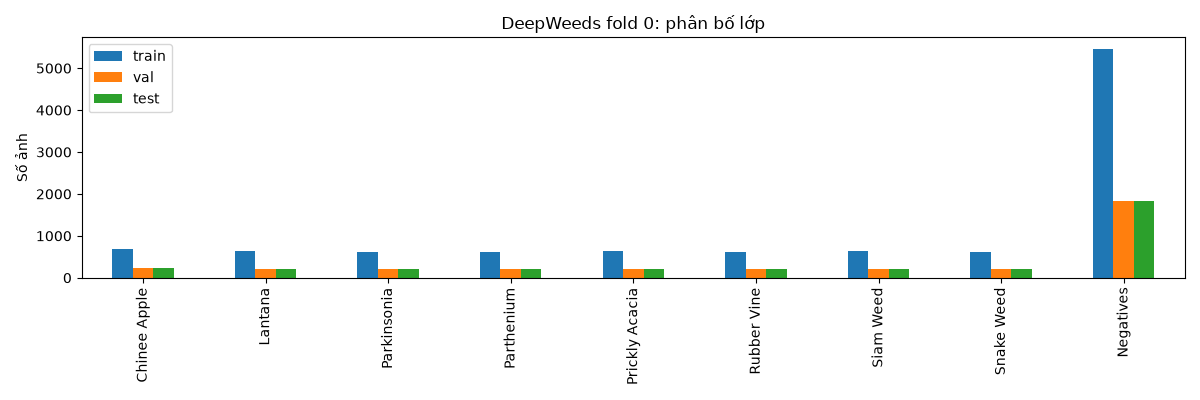

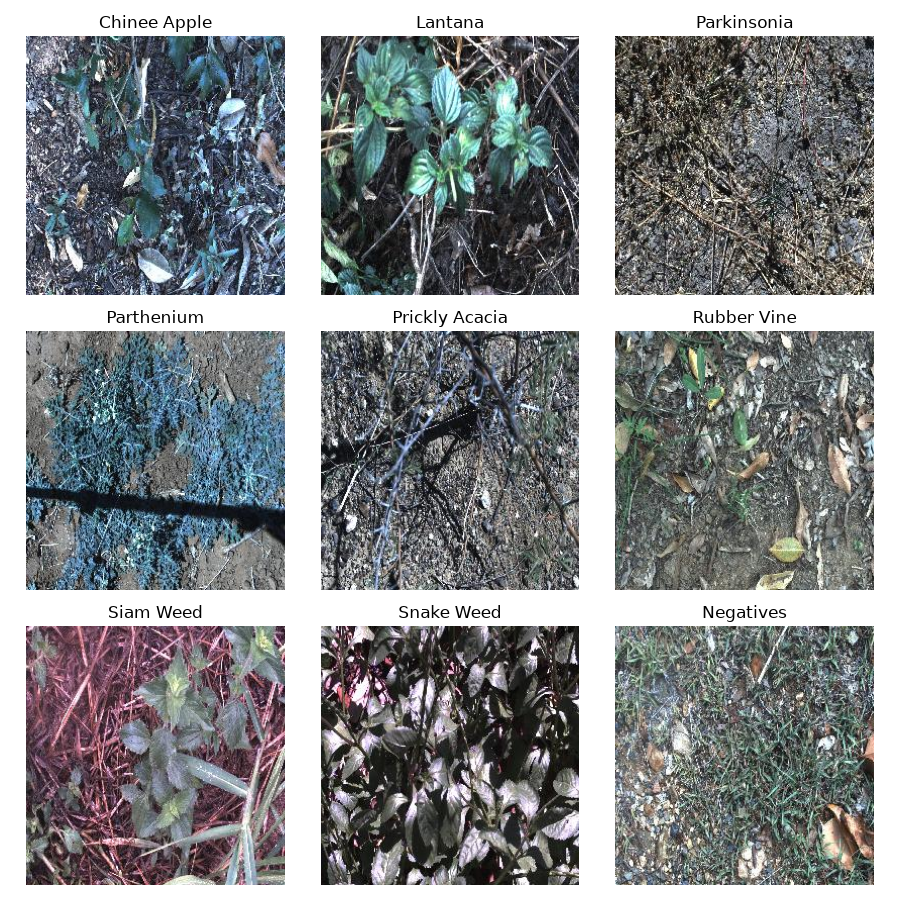

In [5]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("data")
else:
    (train_df, val_df, test_df), split_info = lab.prepare_data()
    import matplotlib.pyplot as plt
    from PIL import Image
    import dataset
    counts = pd.DataFrame({s: pd.Series(split_info["per_class"][s]).sort_index()
                           for s in ("train", "val", "test")}).fillna(0)
    counts.index = dataset.CLASS_NAMES
    counts.plot.bar(figsize=(12, 4), title="DeepWeeds fold 0: phân bố lớp")
    plt.ylabel("Số ảnh"); plt.tight_layout()
    plt.savefig(lab.curves / "eda_classes.png"); plt.show()
    display(counts.astype(int))
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for label, ax in enumerate(axes.ravel()):
        name = train_df[train_df.Label == label].iloc[0].Filename
        with Image.open(lab.images / name) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(dataset.CLASS_NAMES[label]); ax.axis("off")
    plt.tight_layout(); plt.savefig(lab.curves / "eda_samples.png"); plt.show()
    print("Negative chiếm", round(100 * counts.loc["Negatives"].sum() / counts.values.sum(), 1), "% tổng ảnh.")


## 5. Kiểm tra loss, augmentation và overfit một batch trên GPU


**Kết quả lượt train local đã lưu — không train/test lại.**

Các kiểm tra và overfit batch dưới đây được thực hiện trước huấn luyện, lấy từ pipeline_checks.json và log gốc.

STAGE: checks =
[PASS] focal gamma=0 == CE focal=2.61639360 ce=2.61639360
[PASS] label smoothing eps=0 == CE ls=2.73039484 ce=2.73039484
[PASS] CutMix lam/area lam=0.371, tỉ lệ pixel đổi~0.472
[PASS] Mixup trộn nhãn lam=0.859
fuse_conv_bn: đã gộp 1 cặp Conv+BN
[PASS] fuse_conv_bn sai số <= 1e-5 max|Δ|=5.96e-07
[PASS] temperature scaling giảm NLL/ECE T=0.050, ECE 0.3327 -> 0.0206
lab_day2.ipynb:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  },
Initial loss: 2.11035418510437 | ln(9): 2.1972245773362196
Overfit 1 batch: 2.11035418510437 -> 0.013065019622445107 | steps: 16


,initial_loss,ln(9),overfit_loss,steps,checks_passed,checks_total
0,2.110354,2.197225,0.013065,16,6,6


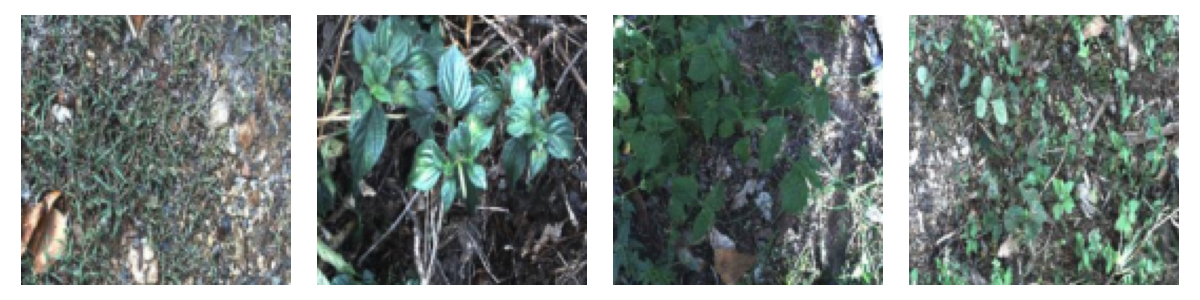

In [6]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("checks")
else:
    import self_test, model, train
    train.set_seed(0)
    checks = [self_test.test_focal_gamma0_equals_ce(), self_test.test_ls_eps0_equals_ce(),
              self_test.test_cutmix_area(), self_test.test_mixup_label(),
              self_test.test_fuse_conv_bn(), self_test.test_temperature()]
    assert all(checks), "Dừng: có kiểm tra pipeline chưa đạt."
    train.set_seed(0)
    check_cfg = lab.cfg()
    torch.backends.cudnn.benchmark = check_cfg.cudnn_benchmark
    tf = dataset.build_transforms(True, check_cfg.img_size, "basic")
    loader = dataset.make_loader(train_df.iloc[:16], lab.images, tf, 8, True, num_workers=0)
    x, y, _ = next(iter(loader))
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for image, ax in zip(x[:4], axes):
        visible = image.permute(1, 2, 0).numpy() * np.array(dataset.IMAGENET_STD) + np.array(dataset.IMAGENET_MEAN)
        ax.imshow(visible.clip(0, 1)); ax.axis("off")
    plt.tight_layout(); plt.savefig(lab.curves / "augmentation.png"); plt.show()
    m = model.build_model("resnet18", pretrained=False, img_size=check_cfg.img_size).cuda()
    x, y = x.cuda(), y.cuda()
    m.train()
    with torch.no_grad():
        initial = torch.nn.functional.cross_entropy(m(x), y).item()
    print("Initial loss:", initial, "| ln(9):", np.log(9))
    assert abs(initial - np.log(9)) < 1.0
    m.train(); optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)
    first = None
    for step in range(60):
        optimizer.zero_grad(set_to_none=True)
        loss = torch.nn.functional.cross_entropy(m(x), y)
        loss.backward(); optimizer.step()
        if first is None: first = loss.item()
        if step >= 15 and loss.item() < 0.05: break
    print("Overfit 1 batch:", first, "->", loss.item(), "| steps:", step + 1)
    assert loss.item() < 0.05, "Batch chưa overfit; kiểm tra dữ liệu/loss trước khi chạy tiếp."
    write_json(lab.runs / "pipeline_checks.json", dict(initial_loss=initial, overfit_loss=loss.item(), steps=step+1, checks=checks))
    del m, x, y, loader, optimizer
    torch.cuda.empty_cache()
    lab.persist()


## 6. So sánh 5 backbone

Output gốc: cùng fold0/seed0/128px/batch64/FP32, 1epoch. Khi train lại, batch/precision chọn theo GPU.

**Kết quả lượt train local đã lưu — không train/test lại.**

Năm backbone: cùng fold/seed0/công thức/128px/1epoch. DeiT tiny đi tiếp theo validation và ngân sách GPU.

STAGE: backbone_table =
KIỂM TRA CHIA DỮ LIỆU (fold 0)
Số ảnh: train=10501 val=3501 test=3507 tổng=17509 (tỉ lệ 0.600/0.200/0.200)
Giao các tập: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh

Số ảnh mỗi lớp (Label: train/val/test):
  0   Chinee Apple:   675 /   225 /   226
  1        Lantana:   637 /   213 /   213
  2    Parkinsonia:   618 /   206 /   207
  3     Parthenium:   613 /   204 /   205
  4 Prickly Acacia:   637 /   212 /   213
  5    Rubber Vine:   605 /   202 /   202
  6      Siam Weed:   644 /   215 /   215
  7     Snake Weed:   609 /   203 /   204
  8      Negatives:  5463 /  1821 /  1822
[B01 s0] epoch  1/1 train_loss 1.4876 val_loss 1.3254 val_macroF1 0.1158 val_top1 0.5284 (89.1s)
[B01 s0] XONG. val macro-F1=0.1158 (epoch 1)
KIỂM TRA CHIA DỮ LIỆU (fold 0)
Số ảnh: train=10501 val=3501 test=3507 tổng=17509 (tỉ lệ 0.600/0.200/0.200)
Giao các tập: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh

Số ảnh mỗi lớp (Label: train/v

,exp_id,backbone,tag trọng số,#params (M),GMAC,độ phân giải,epoch,seed,macro-F1 val,top-1 val,train/epoch (s),độ trễ batch-1 (ms),ghi chú
0,B01,resnet18,a1_in1k,11.18,0.592188,128,1,0,0.1158,0.5284,89.1,5.13,best epoch 1
1,B02,resnet34,a1_in1k,21.29,1.196168,128,1,0,0.0929,0.5247,57.5,10.04,best epoch 1
2,B03,convnext_atto,d2_in1k,3.38,0.178619,128,1,0,0.7128,0.7969,82.9,8.76,best epoch 1
3,B04,deit_tiny_patch16_224,fb_in1k,5.50,0.354486,128,1,0,0.7289,0.8066,54.4,8.22,best epoch 1
4,B05,mobilenetv3_large_100,ra_in1k,4.21,0.072159,128,1,0,0.4532,0.6084,46.9,11.63,best epoch 1


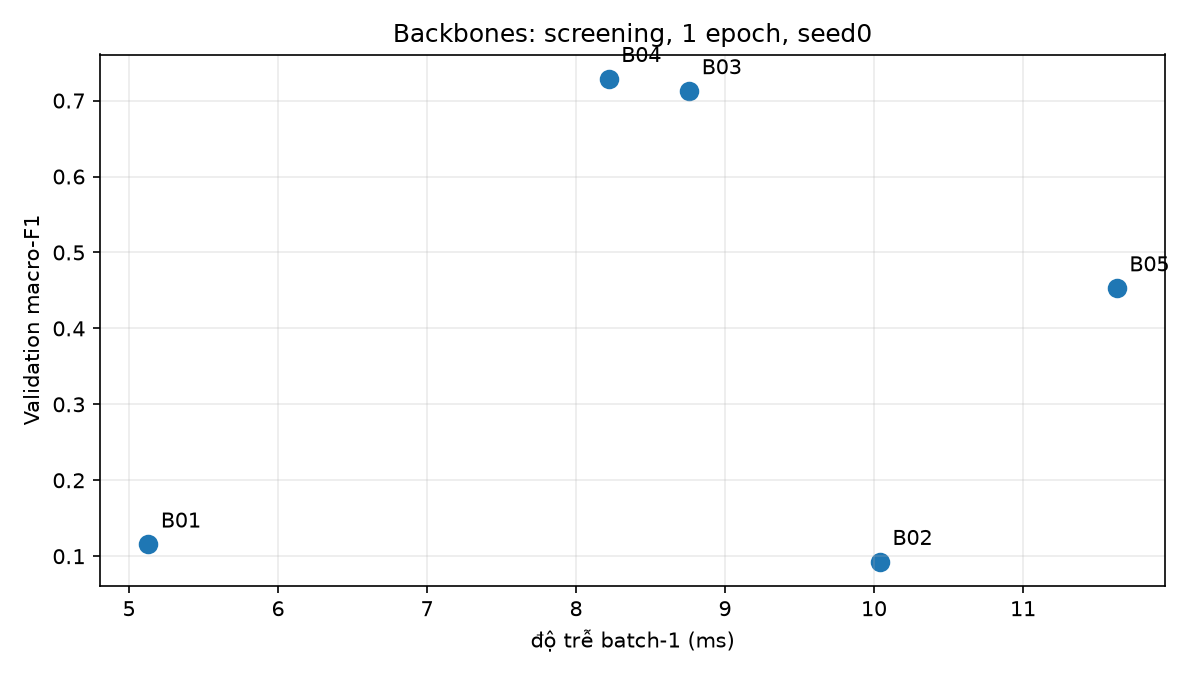

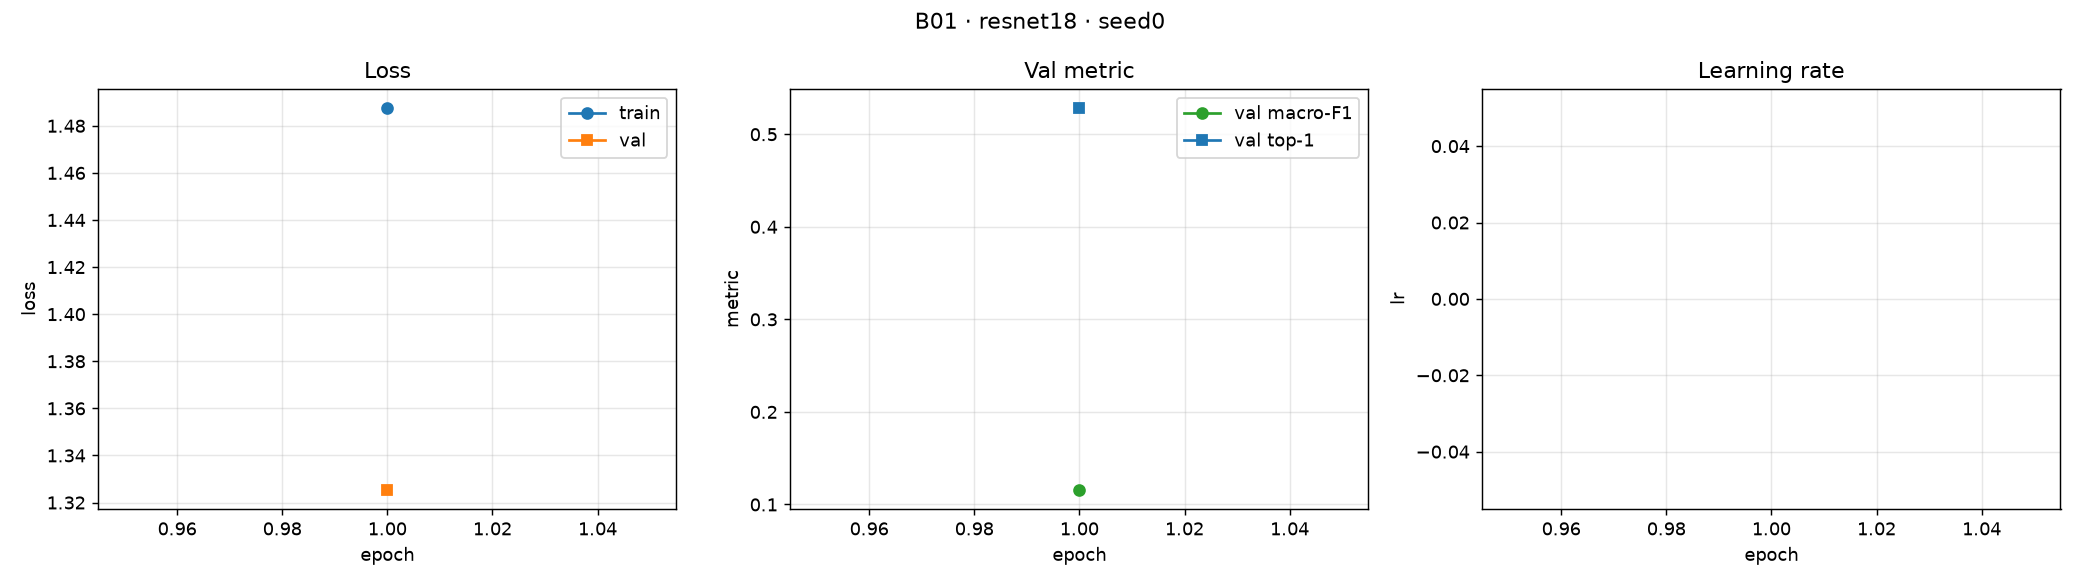

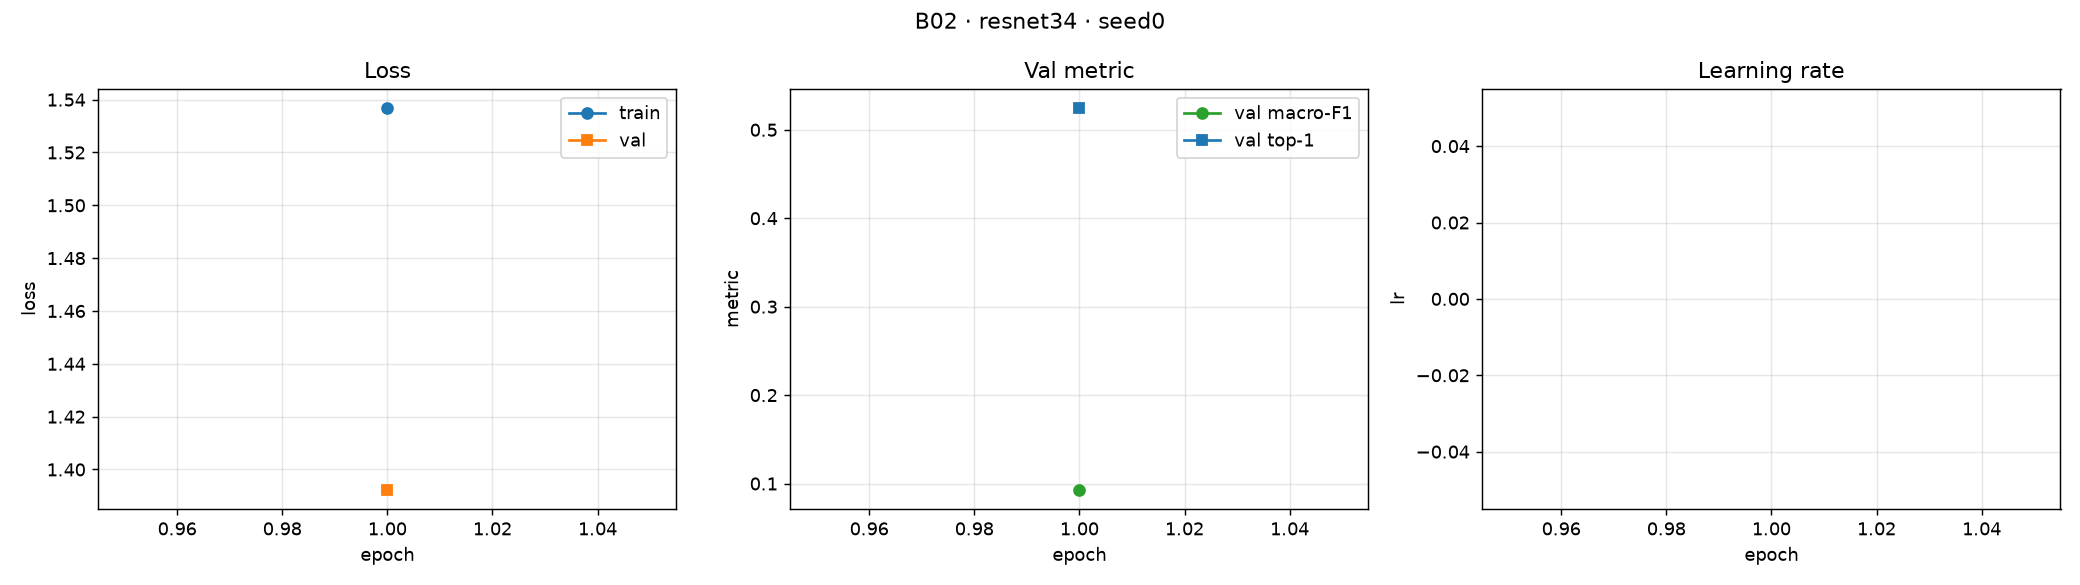

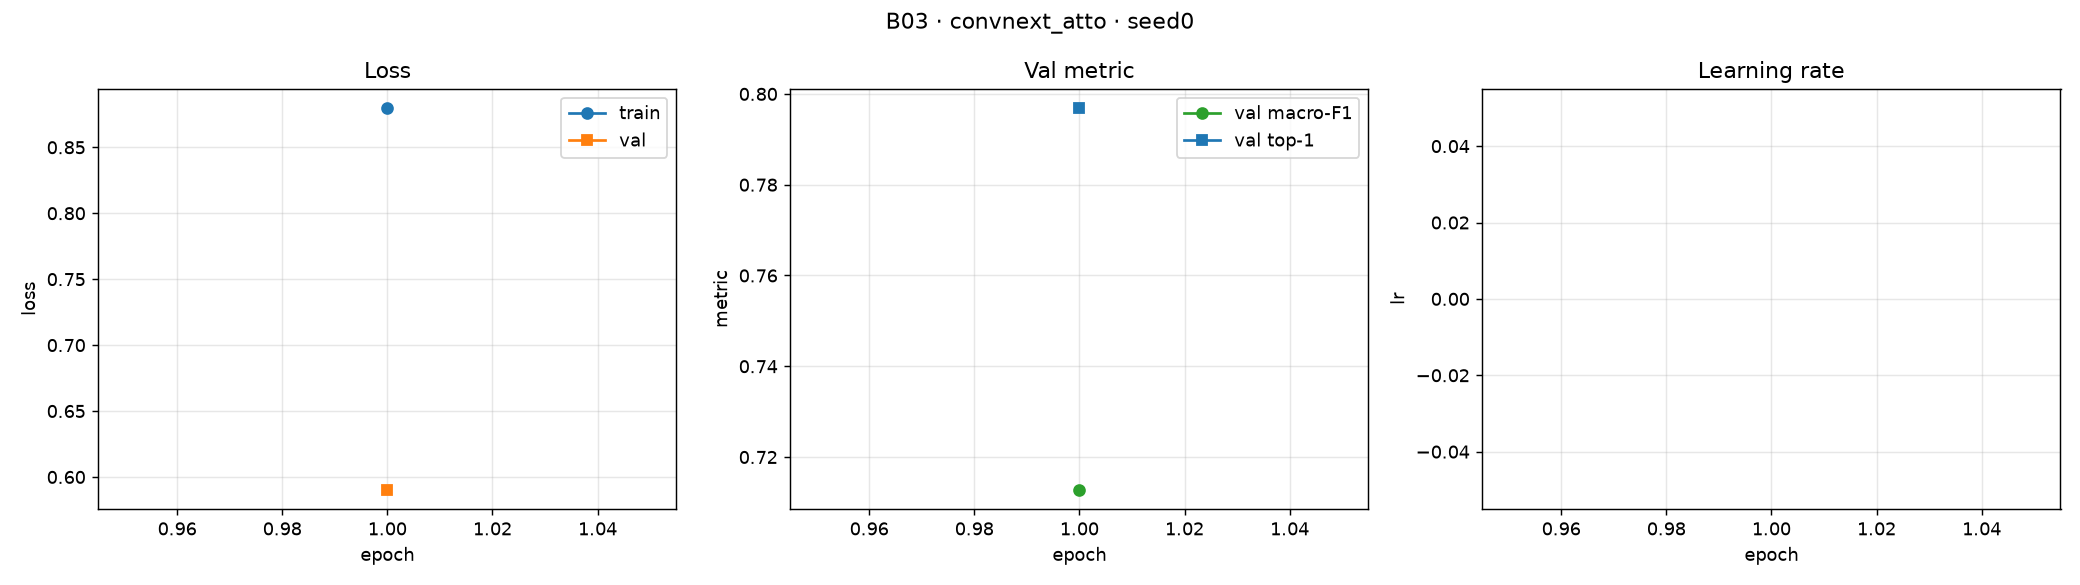

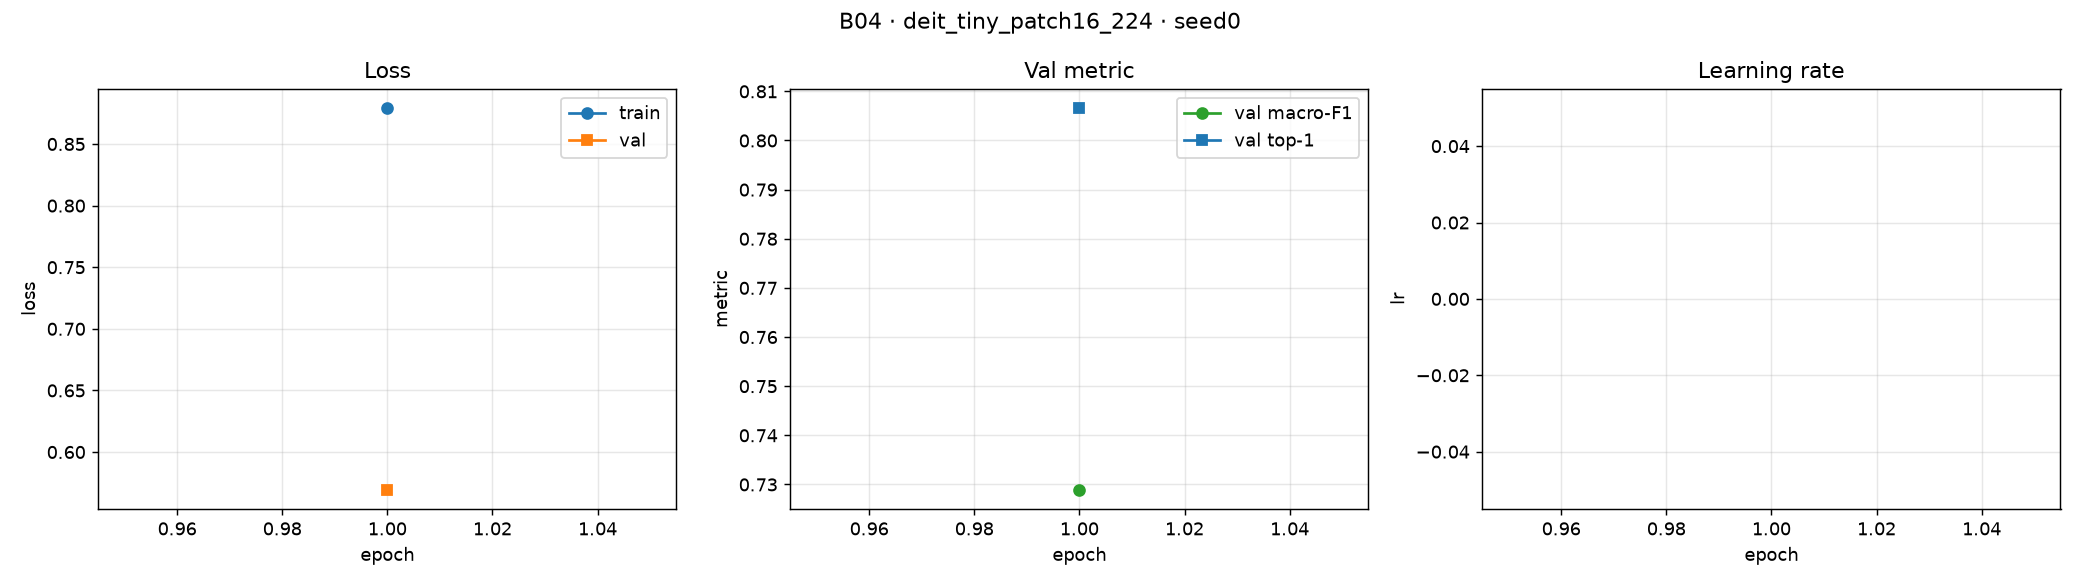

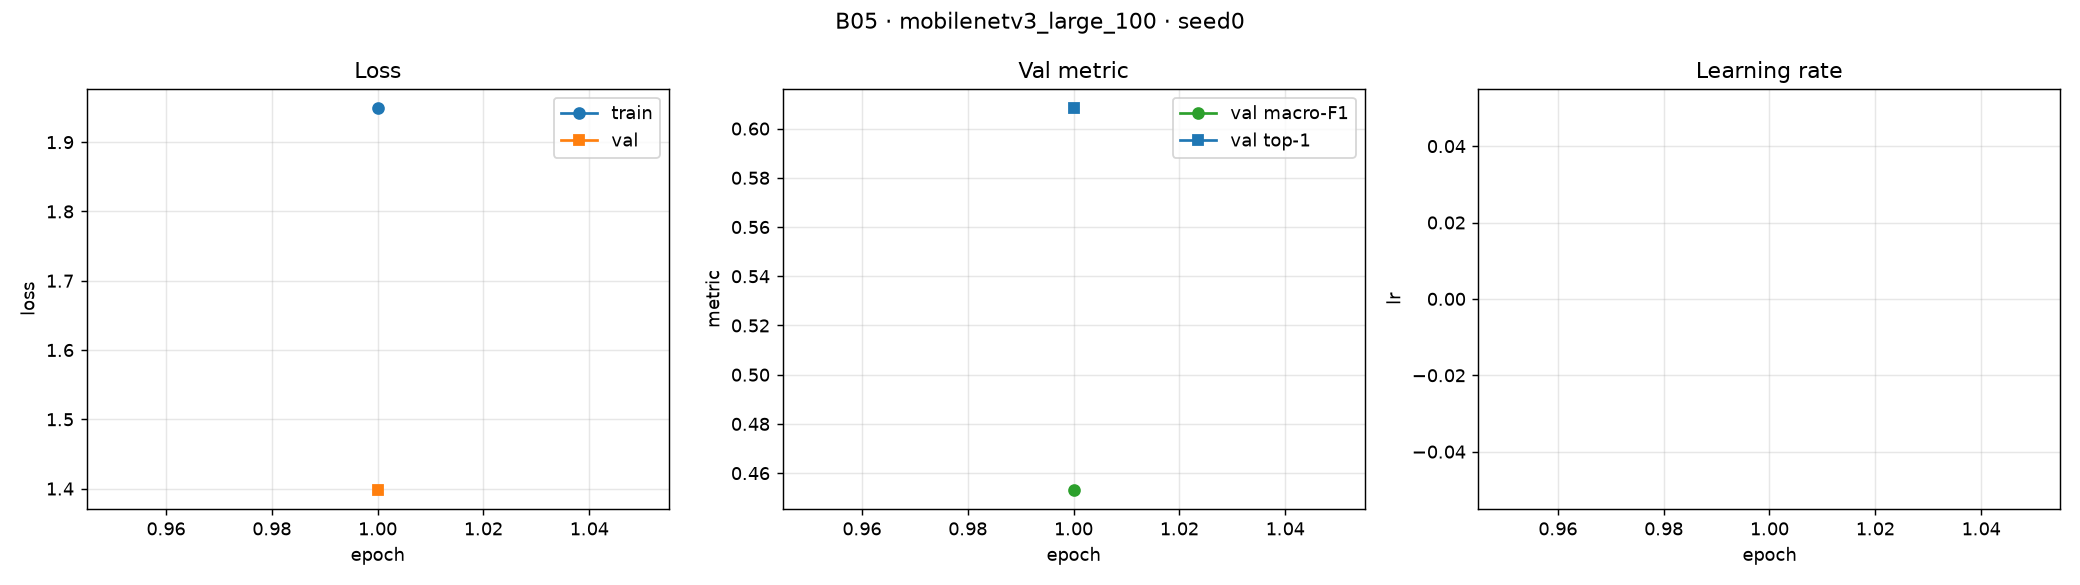

In [7]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("backbones")
else:
    backbone_table = lab.backbones()
    display(backbone_table[["exp_id", "backbone", "val_macro_f1", "val_top1", "train_time_per_epoch_s"]])
    print("Chọn trên val:", lab.chosen["backbone"])
    print("Thời gian đã chạy (phút):", round((time.perf_counter() - STARTED) / 60, 1))


## 7. Ba trục huấn luyện và một kết hợp

`TS00` dùng lại model backbone thắng với cùng cấu hình, không train thêm.
`T01`: frozen vs fine-tune; `T03`: color vs basic; `T07`: label smoothing vs CE.
`T14`: color + label smoothing để kiểm tra kết hợp. Mỗi thử nghiệm đơn chỉ thay một yếu tố.
`full` thêm scratch, CutMix, focal. Chọn công thức theo macro-F1 val, không xem test.
`T00` ở chung kết sẽ có ngân sách epoch bằng `F01`; bảng ablation so với `TS00`.


**Kết quả lượt train local đã lưu — không train/test lại.**

So ablation với TS00 ở cùng 1epoch; T00 là mốc 12epoch cuối cùng. Color+LS không thắng; giữ finetune/basic/CE.

STAGE: ablation_table =
KIỂM TRA CHIA DỮ LIỆU (fold 0)
Số ảnh: train=10501 val=3501 test=3507 tổng=17509 (tỉ lệ 0.600/0.200/0.200)
Giao các tập: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh

Số ảnh mỗi lớp (Label: train/val/test):
  0   Chinee Apple:   675 /   225 /   226
  1        Lantana:   637 /   213 /   213
  2    Parkinsonia:   618 /   206 /   207
  3     Parthenium:   613 /   204 /   205
  4 Prickly Acacia:   637 /   212 /   213
  5    Rubber Vine:   605 /   202 /   202
  6      Siam Weed:   644 /   215 /   215
  7     Snake Weed:   609 /   203 /   204
  8      Negatives:  5463 /  1821 /  1822
[T01 s0] epoch  1/1 train_loss 1.3714 val_loss 1.1996 val_macroF1 0.3343 val_top1 0.5813 (38.5s)
[T01 s0] XONG. val macro-F1=0.3343 (epoch 1)
KIỂM TRA CHIA DỮ LIỆU (fold 0)
Số ảnh: train=10501 val=3501 test=3507 tổng=17509 (tỉ lệ 0.600/0.200/0.200)
Giao các tập: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh

Số ảnh mỗi lớp (Label: train/v

,exp_id,backbone,trục thay đổi,khác T00 ở,seed,macro-F1 val,top-1 val,mốc so sánh,Δ so với mốc,epoch tối đa,epoch đã chạy,ghi chú,F1 Chinee apple val,F1 Snake weed val,nguồn log,so sánh công bằng
0,T00,deit_tiny_patch16_224,nền,init=finetune aug=basic loss=ce mix=None sampl...,0,0.9081,0.9337,T00,0.0000,12,12,Dùng lại F01/seed0; cấu hình huấn luyện giống hệt,0.828947,0.840000,evidence/runs/T00/seed0/history.csv,"12 epochs, matched seed"
1,T00,deit_tiny_patch16_224,nền,init=finetune aug=basic loss=ce mix=None sampl...,1,0.9171,0.9377,T00,0.0000,12,12,Dùng lại F01/seed1; cấu hình huấn luyện giống hệt,0.843750,0.835443,evidence/runs/T00/seed1/history.csv,"12 epochs, matched seed"
2,T00,deit_tiny_patch16_224,nền,init=finetune aug=basic loss=ce mix=None sampl...,2,0.9106,0.9343,T00,0.0000,12,12,Dùng lại F01/seed2; cấu hình huấn luyện giống hệt,0.838710,0.822695,evidence/runs/T00/seed2/history.csv,"12 epochs, matched seed"
3,T01,deit_tiny_patch16_224,A. khởi tạo (frozen),init=frozen aug=basic loss=ce mix=None sampler...,0,0.3343,0.5813,TS00,-0.3947,1,1,NaN,0.349854,0.344828,evidence/runs/T01/seed0/history.csv,"1 epoch, seed0, vs TS00"
4,T03,deit_tiny_patch16_224,B. augmentation (color),init=finetune aug=color loss=ce mix=None sampl...,0,0.6866,0.7812,TS00,-0.0423,1,1,NaN,0.577889,0.588235,evidence/runs/T03/seed0/history.csv,"1 epoch, seed0, vs TS00"
5,T07,deit_tiny_patch16_224,C. loss (label smoothing),init=finetune aug=basic loss=ls mix=None sampl...,0,0.7258,0.8049,TS00,-0.0031,1,1,NaN,0.580796,0.622108,evidence/runs/T07/seed0/history.csv,"1 epoch, seed0, vs TS00"
6,T14,deit_tiny_patch16_224,kết hợp color + label smoothing,init=finetune aug=color loss=ls mix=None sampl...,0,0.6880,0.7823,TS00,-0.0409,1,1,NaN,0.562025,0.604396,evidence/runs/T14/seed0/history.csv,"1 epoch, seed0, vs TS00"
7,TS00,deit_tiny_patch16_224,nền khảo sát (cùng ngân sách ablation),init=finetune aug=basic loss=ce mix=None sampl...,0,0.7289,0.8066,TS00,0.0000,1,1,Dùng lại B04/seed0; cấu hình huấn luyện giống hệt,0.594966,0.641221,evidence/runs/TS00/seed0/history.csv,"1 epoch, seed0, vs TS00"


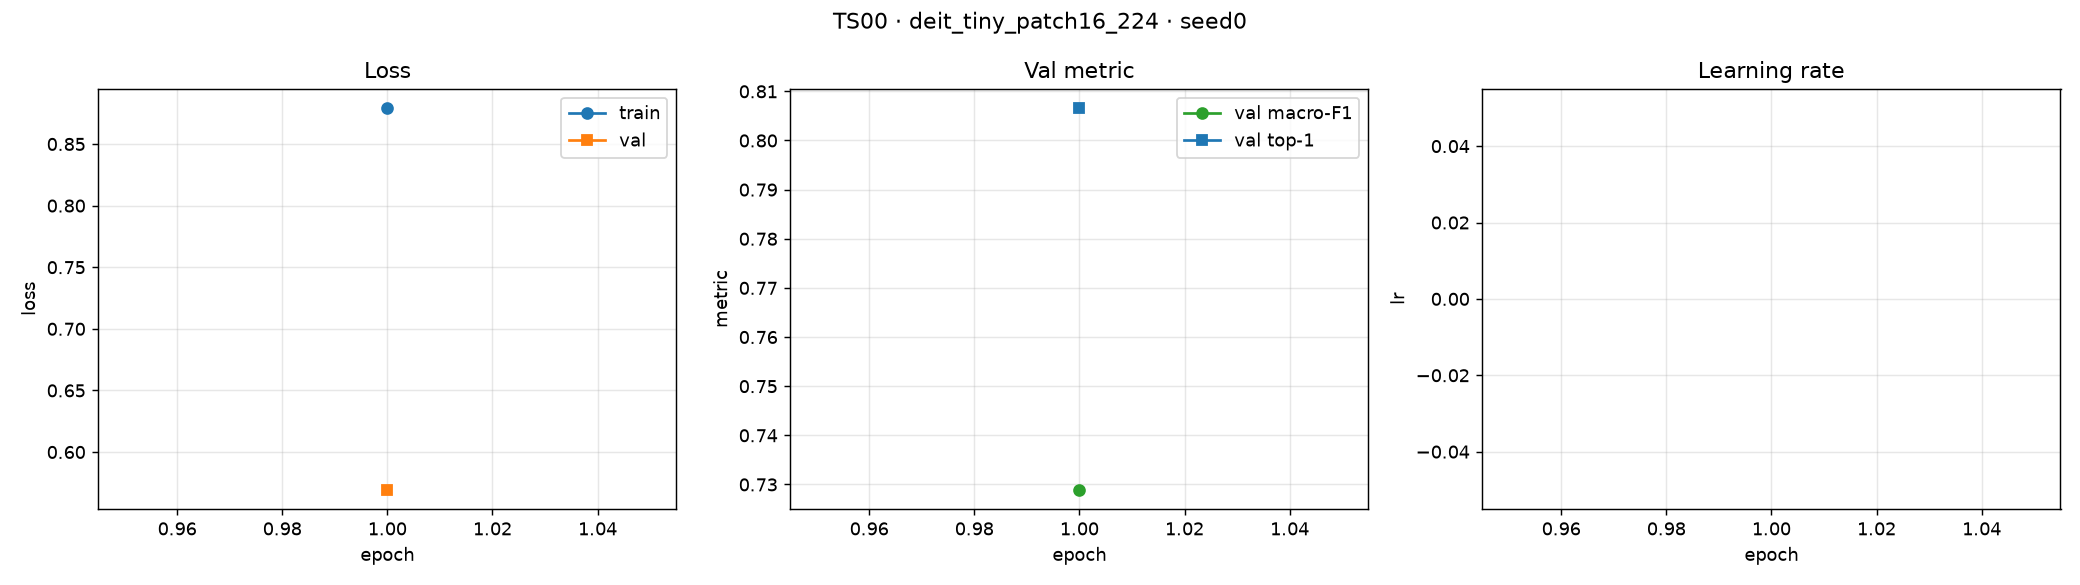

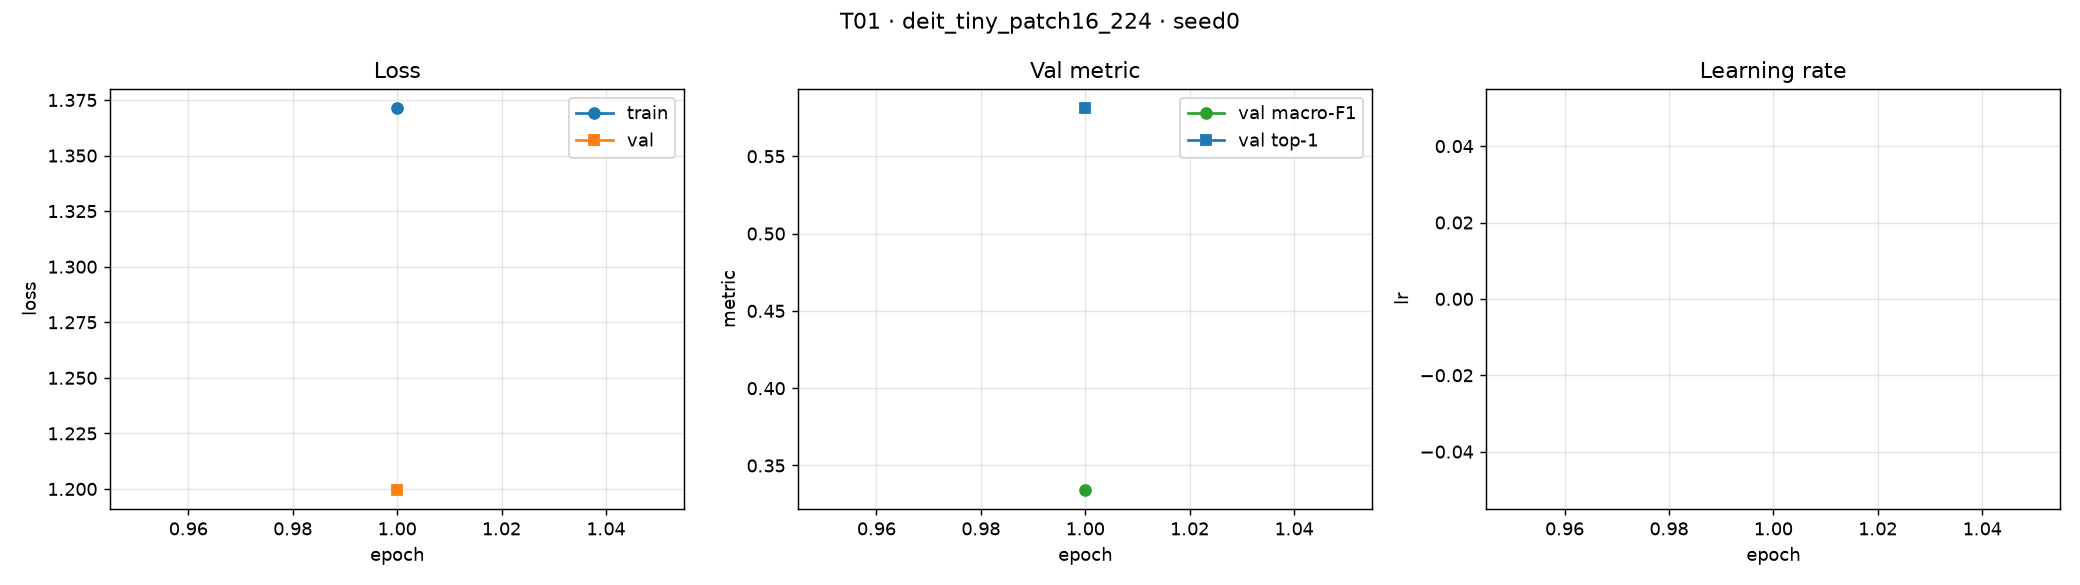

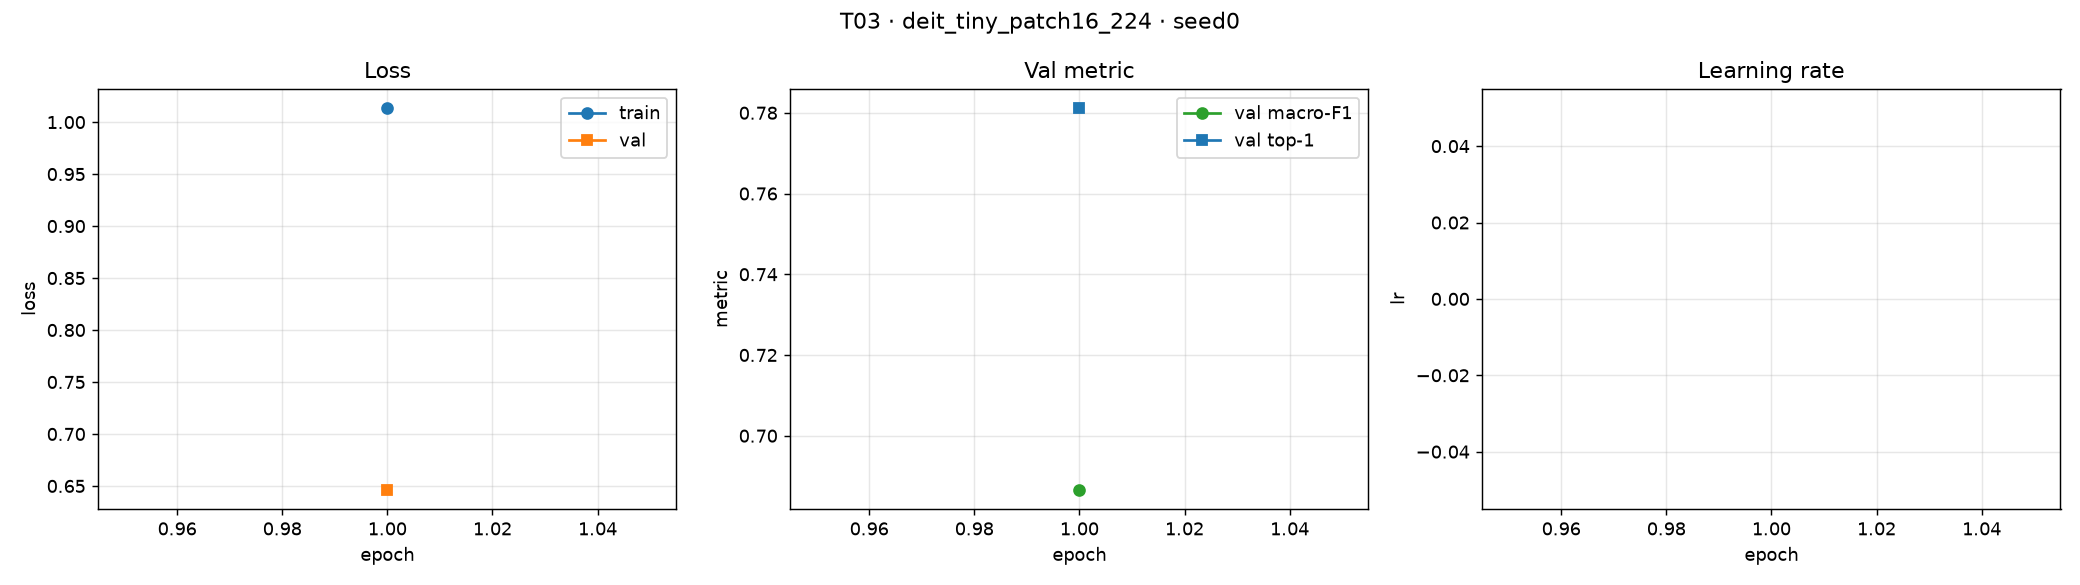

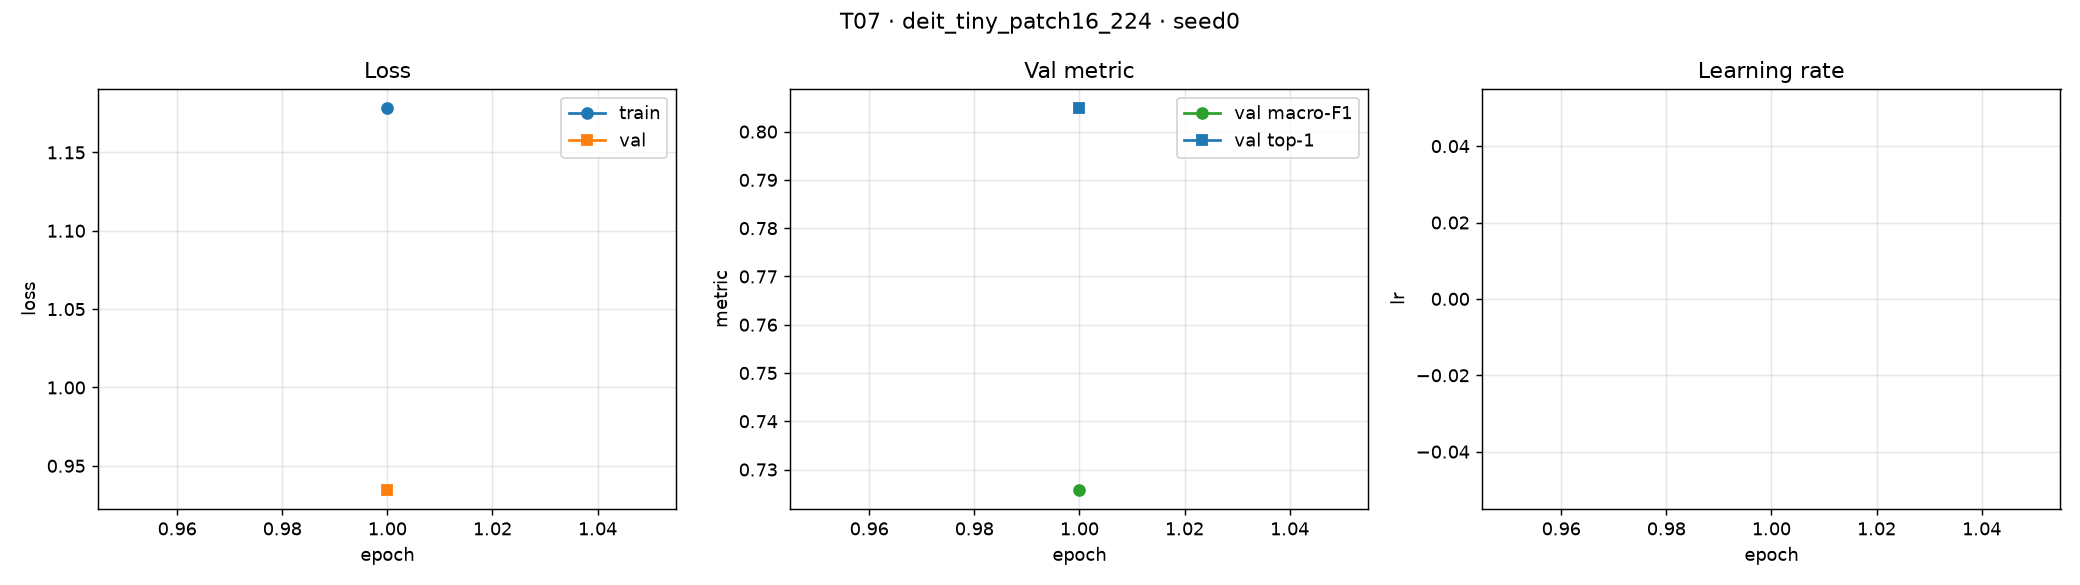

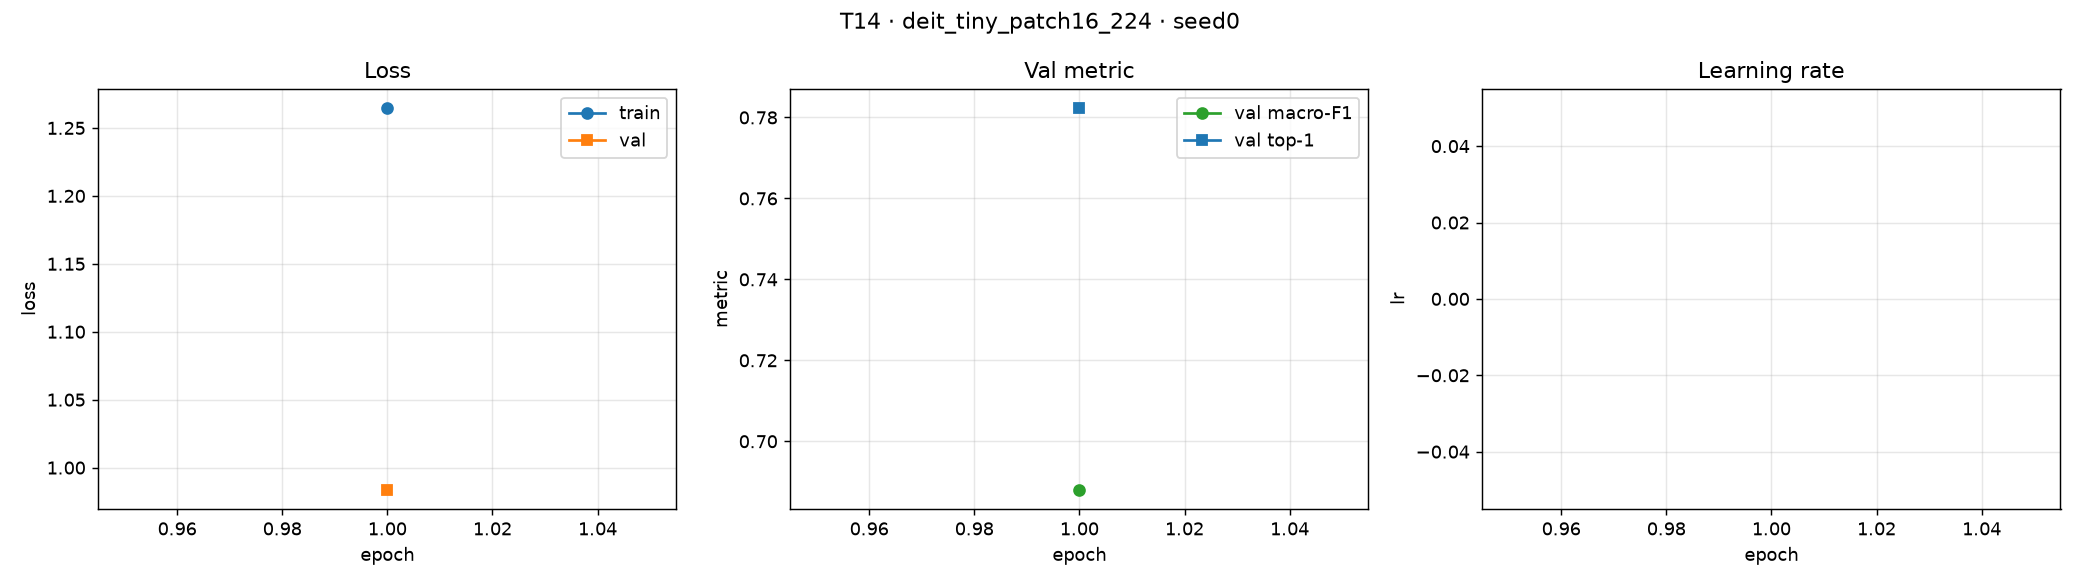

In [8]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("ablations")
else:
    ablation_table = lab.ablations()
    display(ablation_table[["exp_id", "init", "aug", "loss", "val_macro_f1", "delta_vs_TS00"]])
    print("Công thức thắng val:", {k: lab.best[k] for k in ("backbone", "init", "aug", "loss", "mix")})


## 8. Chung kết seed0 và lựa chọn suy luận trên val

Log train gốc và bảng inference. Bảng có đo latency ensemble bổ sung; ghi rõ forward-only gốc so với đo forward+gộp+softmax bổ sung.

**Kết quả lượt train local đã lưu — không train/test lại.**

Chọn suy luận trên val seed0. Bảng dùng phép đo bổ sung 20warmup/100 lượt (forward+aggregate+softmax); log gốc bên dưới dùng forward-only 10/50. Không trộn phạm vi đo.

STAGE: lab.train_final()
KIỂM TRA CHIA DỮ LIỆU (fold 0)
Số ảnh: train=10501 val=3501 test=3507 tổng=17509 (tỉ lệ 0.600/0.200/0.200)
Giao các tập: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh

Số ảnh mỗi lớp (Label: train/val/test):
  0   Chinee Apple:   675 /   225 /   226
  1        Lantana:   637 /   213 /   213
  2    Parkinsonia:   618 /   206 /   207
  3     Parthenium:   613 /   204 /   205
  4 Prickly Acacia:   637 /   212 /   213
  5    Rubber Vine:   605 /   202 /   202
  6      Siam Weed:   644 /   215 /   215
  7     Snake Weed:   609 /   203 /   204
  8      Negatives:  5463 /  1821 /  1822
[F01 s0] epoch  1/12 train_loss 0.8791 val_loss 0.5563 val_macroF1 0.7374 val_top1 0.8075 (54.1s)
[F01 s0] epoch  2/12 train_loss 0.4445 val_loss 0.3829 val_macroF1 0.8154 val_top1 0.8660 (26.6s)
[F01 s0] epoch  3/12 train_loss 0.3358 val_loss 0.3457 val_macroF1 0.8405 val_top1 0.8800 (26.7s)
[F01 s0] epoch  4/12 train_loss 0.2678 val_loss 0.3168 val_macroF1 0.8

,exp_id,phương pháp,mô hình/checkpoint,K,macro-F1 val,top-1 val,ECE val,p50 (ms),p95 (ms),p99 (ms),ảnh/s,chi phí so với I00,ghi chú
0,I00,1-view FP32,F01/seed0,1,0.908103,0.933733,0.024263,8.44800,11.993200,12.422464,118.371212,1.000000,; timing: GPU forward + aggregate + softmax; 2...
1,I01,hflip / mean probability,F01/seed0,2,0.918195,0.940874,0.017188,17.21885,30.325455,31.261544,58.075888,2.038216,; timing: GPU forward + aggregate + softmax; 2...
2,I03,hflip / mean logits,F01/seed0,2,0.918199,0.940588,0.020968,17.11420,28.815960,31.317995,58.431010,2.025829,; timing: GPU forward + aggregate + softmax; 2...
3,I07,temperature scaling,F01/seed0,1,0.908103,0.933733,0.005424,8.50095,11.943910,14.949122,117.633911,1.006268,T=1.3548; fitted on val; calibration overhead ...
4,I05,ensemble 2 backbones,B04/seed0+B03/seed0,2,0.754170,0.824907,0.078587,20.27300,29.388545,32.220838,49.326691,2.399740,"B04+B03, both screening 1 epoch; unequal train..."


,cấu hình,GPU,dtype,batch,gộp BN,p50 (ms),p95 (ms),p99 (ms),ảnh/s,warmup,n_iters,độ phân giải,phạm vi đo
0,I00,NVIDIA GeForce GTX 1650,fp32,1,không,8.44800,11.993200,12.422464,118.371212,20,100,128,GPU forward + aggregation + softmax; excludes ...
1,I01,NVIDIA GeForce GTX 1650,fp32,1,không,17.21885,30.325455,31.261544,58.075888,20,100,128,GPU forward + aggregation + softmax; excludes ...
2,I03,NVIDIA GeForce GTX 1650,fp32,1,không,17.11420,28.815960,31.317995,58.431010,20,100,128,GPU forward + aggregation + softmax; excludes ...
3,I05,NVIDIA GeForce GTX 1650,fp32,1,không,20.27300,29.388545,32.220838,49.326691,20,100,128,GPU forward + aggregation + softmax; excludes ...
4,I07,NVIDIA GeForce GTX 1650,fp32,1,không,8.50095,11.943910,14.949122,117.633911,20,100,128,GPU forward + aggregation + softmax; excludes ...
5,F01,NVIDIA GeForce GTX 1650,fp32,1,không,17.29760,26.681120,30.957878,57.811488,20,100,128,GPU forward + aggregation + softmax; excludes ...


Phương pháp đã chốt trước test: hflip_logit


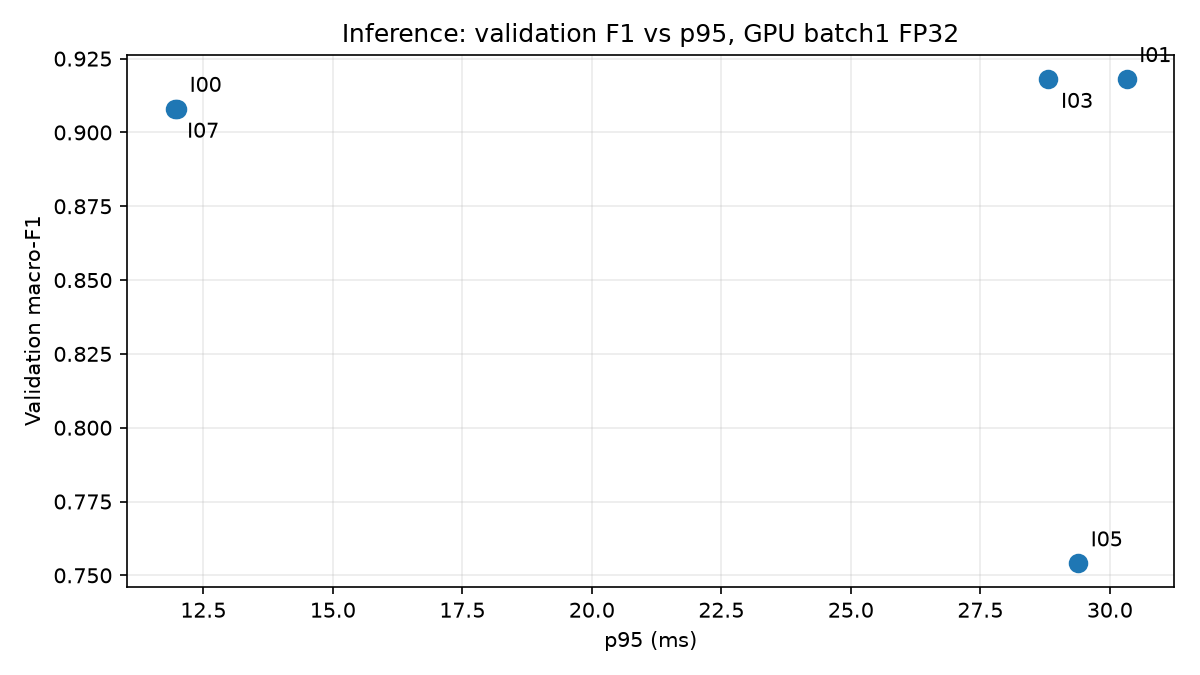

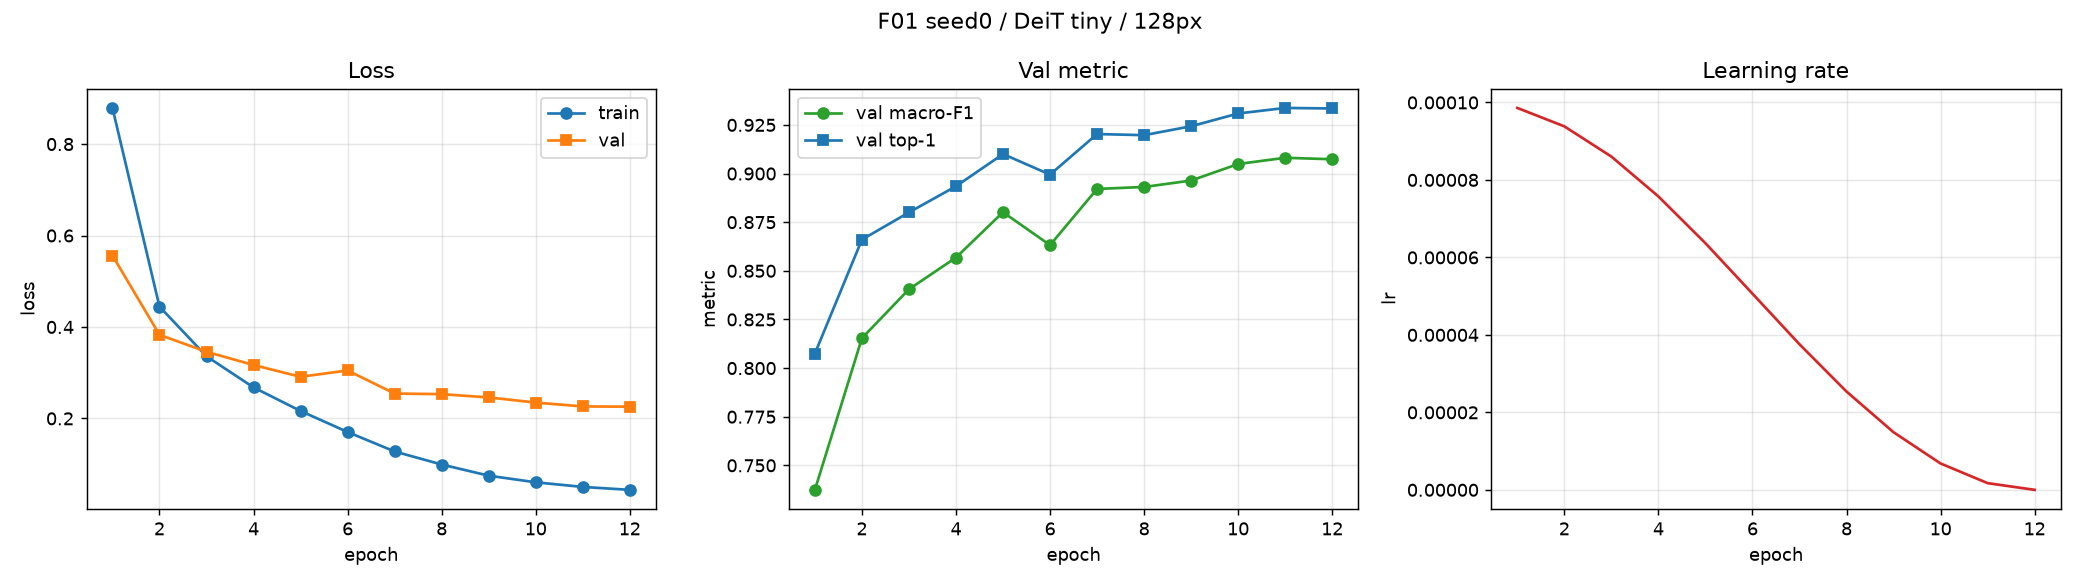

In [9]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("inference")
else:
    lab.train_final()
    inference_table = lab.inference_study()
    display(inference_table)
    if PROFILE != "smoke":
        print("Phương pháp đã chốt:", lab.method)


## 9. Chung kết và mốc: ba seed, test cuối cùng

Train các seed còn lại trước khi đọc kết quả test. Giữ toàn bộ train/val/test fold 0.
T được fit trên val riêng từng seed. Dự đoán có/không T dùng cùng logits, không chạy test lại.
Mỗi lần đánh giá có manifest; chạy lại notebook sẽ dùng file đã hoàn tất.
Drive lưu sau mỗi thí nghiệm. Nếu bị ngắt giữa một lần train, thí nghiệm đang dở sẽ train lại;
các thí nghiệm đã xong được dùng lại. Nếu bị ngắt giữa test, notebook dừng để bạn kiểm tra
manifest/dự đoán, tránh tự chạy test lần nữa.


**Kết quả lượt train local đã lưu — không train/test lại.**

Log train seed1/2 và test cuối cùng (cũ). Mỗi CSV test đủ 3.507 ảnh; bản uncal dùng cùng logits. Kernel này không gọi model hoặc test.

STAGE: lab.finals()
Dùng lại F01/seed0
KIỂM TRA CHIA DỮ LIỆU (fold 0)
Số ảnh: train=10501 val=3501 test=3507 tổng=17509 (tỉ lệ 0.600/0.200/0.200)
Giao các tập: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Hợp ba tập: 17509 ảnh

Số ảnh mỗi lớp (Label: train/val/test):
  0   Chinee Apple:   675 /   225 /   226
  1        Lantana:   637 /   213 /   213
  2    Parkinsonia:   618 /   206 /   207
  3     Parthenium:   613 /   204 /   205
  4 Prickly Acacia:   637 /   212 /   213
  5    Rubber Vine:   605 /   202 /   202
  6      Siam Weed:   644 /   215 /   215
  7     Snake Weed:   609 /   203 /   204
  8      Negatives:  5463 /  1821 /  1822
[F01 s1] epoch  1/12 train_loss 0.8862 val_loss 0.5818 val_macroF1 0.6950 val_top1 0.7986 (54.6s)
[F01 s1] epoch  2/12 train_loss 0.4560 val_loss 0.3833 val_macroF1 0.8180 val_top1 0.8658 (27.9s)
[F01 s1] epoch  3/12 train_loss 0.3353 val_loss 0.3654 val_macroF1 0.8295 val_top1 0.8732 (29.1s)
[F01 s1] epoch  4/12 train_loss 0.2865 val_loss 0.3436 v

,exp_id,cấu hình,seed,macro-F1 val,macro-F1 test,top-1 test,ECE test,balanced accuracy test,NLL test,nguồn
0,F01,DeiT tiny / 128px / full finetune / basic / CE...,0,0.918199,0.916225,0.938124,0.00804,0.912449,0.193758,predictions/F01_seed0_test.csv
1,F01,DeiT tiny / 128px / full finetune / basic / CE...,1,0.917791,0.916663,0.938694,0.007132,0.913889,0.188154,predictions/F01_seed1_test.csv
2,F01,DeiT tiny / 128px / full finetune / basic / CE...,2,0.914811,0.908794,0.933276,0.011778,0.904499,0.193598,predictions/F01_seed2_test.csv
3,F01,DeiT tiny / 128px / full finetune / basic / CE...,"mean ± std (0,1,2; ddof=1)",0.9169 ± 0.0018,0.9139 ± 0.0044,0.9367 ± 0.0030,0.0090 ± 0.0025,0.9103 ± 0.0051,0.1918 ± 0.0032,evidence/evaluation/F01_summary.json
4,T00,DeiT tiny / 128px / full finetune / basic / CE...,0,0.908103,0.916948,0.938694,0.023297,0.914112,0.220691,predictions/T00_seed0_test.csv
5,T00,DeiT tiny / 128px / full finetune / basic / CE...,1,0.917067,0.907895,0.93128,0.02706,0.904563,0.212124,predictions/T00_seed1_test.csv
6,T00,DeiT tiny / 128px / full finetune / basic / CE...,2,0.910634,0.906276,0.93071,0.026209,0.902386,0.219627,predictions/T00_seed2_test.csv
7,T00,DeiT tiny / 128px / full finetune / basic / CE...,"mean ± std (0,1,2; ddof=1)",0.9119 ± 0.0046,0.9104 ± 0.0058,0.9336 ± 0.0045,0.0255 ± 0.0020,0.9070 ± 0.0062,0.2175 ± 0.0047,evidence/evaluation/T00_summary.json


,cấu hình,lớp,số ảnh test,precision,precision std,recall,recall std,F1,F1 std
0,F01,Chinee apple,226,0.882047,0.013324,0.792035,0.035121,0.834248,0.018601
1,F01,Lantana,213,0.897473,0.013158,0.901408,0.018779,0.899264,0.005359
2,F01,Parkinsonia,207,0.947579,0.017513,0.982287,0.014759,0.964450,0.004404
3,F01,Parthenium,205,0.952634,0.016856,0.910569,0.007451,0.931041,0.006587
4,F01,Prickly acacia,213,0.914011,0.016494,0.910798,0.018779,0.912212,0.007337
5,F01,Rubber vine,202,0.935409,0.013742,0.904290,0.012458,0.919465,0.002125
6,F01,Siam weed,215,0.945033,0.005760,0.933333,0.011705,0.939139,0.008640
7,F01,Snake weed,204,0.836941,0.036264,0.888889,0.014976,0.861702,0.016698
8,F01,Negative,1822,0.958209,0.002384,0.968899,0.000317,0.963523,0.001246
9,T00,Chinee apple,226,0.881362,0.013897,0.775811,0.022271,0.825010,0.010686


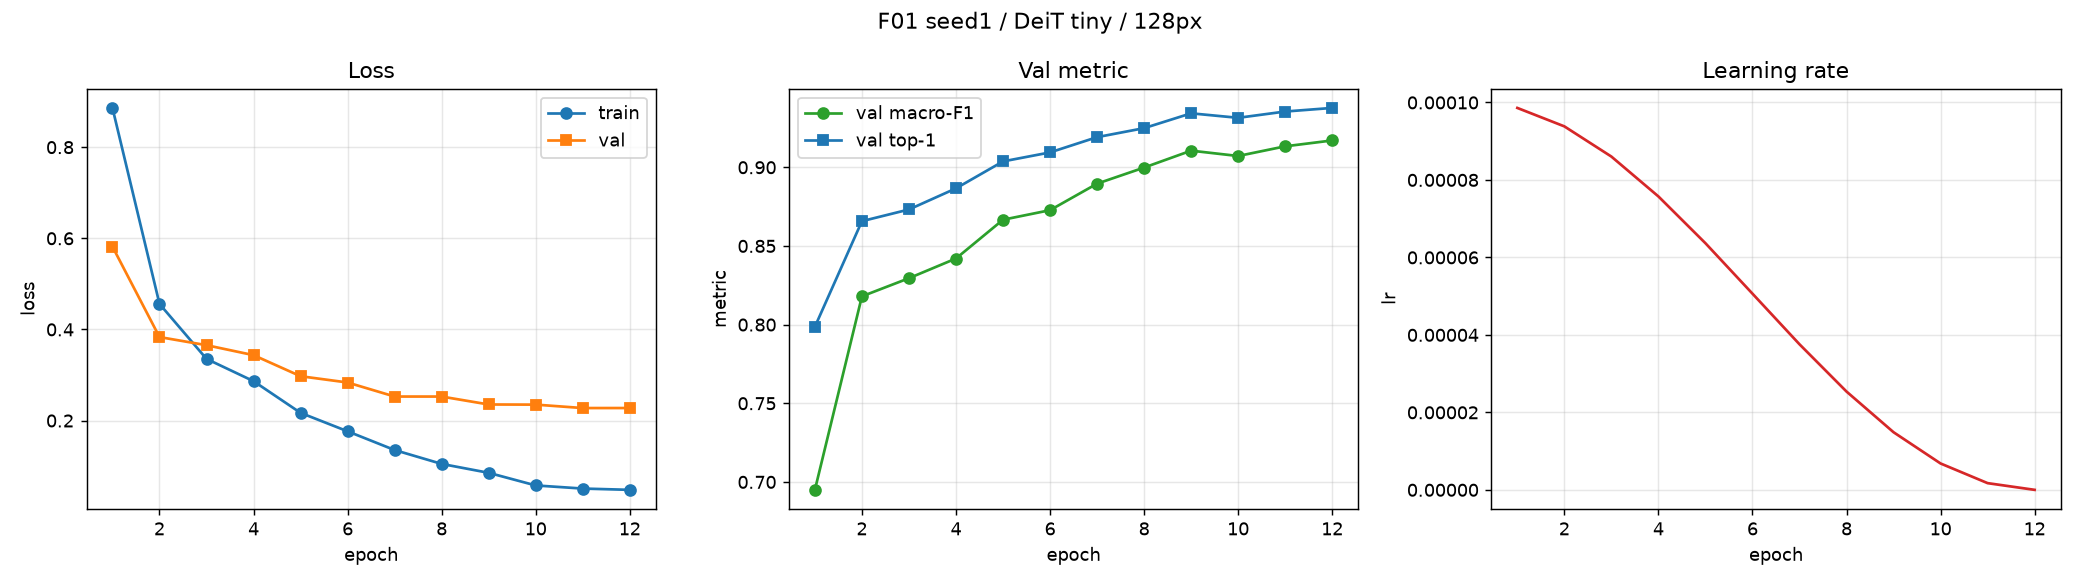

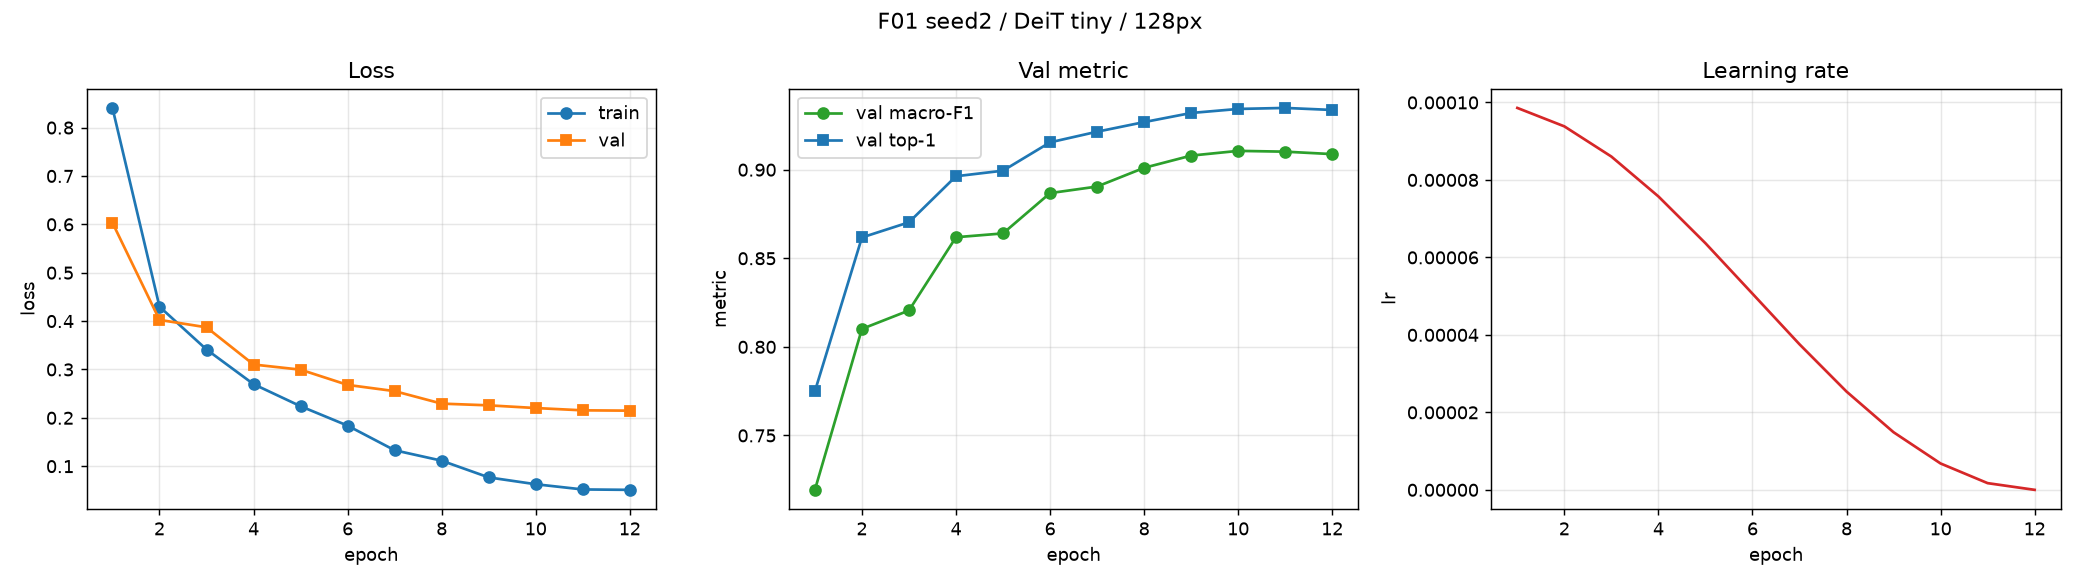

In [10]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("finals")
else:
    lab.finals()


## 10. Kết quả test, phân tích lỗi và workbook

Lượt train tự sinh workbook 7 sheet; bài nộp hoàn thiện có 8 sheet, thêm Robustness. Dữ liệu test được đọc từ CSV cũ; không chạy model/test lại.

**Kết quả lượt train local đã lưu — không train/test lại.**

Kết quả được tính lại từ dự đoán đã lưu bằng eval.py gốc. Mục I: 10/20; không phải tổng điểm bài lab.

,code,criterion,points,max,note
0,I1,Top-1 accuracy test,3,7,93.67% (mean 3 seed)
1,I2,Macro-F1 cải thiện so với mốc,2,5,"final 0.9139, mốc 0.9104, Δ=+0.0035, s=0.0058"
2,I3,Recall hai lớp khó,1,4,"Chinee Apple 79.2% (mốc 88.5%), Snake Weed 88...."
3,I4a,ECE sau TS < ECE trước,1,1,"trước 0.0214, sau 0.0090"
4,I4b,Chênh macro-F1 val/test <= 0.02,1,1,"val 0.9169, test 0.9139, chênh 0.0030"
5,I5,Cấu hình thời gian thực,2,2,"p95 = 26.7 ms (ngân sách 100 ms), đo đúng cách"


Mục I: 10 / 20
Workbook có 8 sheet | dự đoán 3 seed | thời gian train 36,18 phút


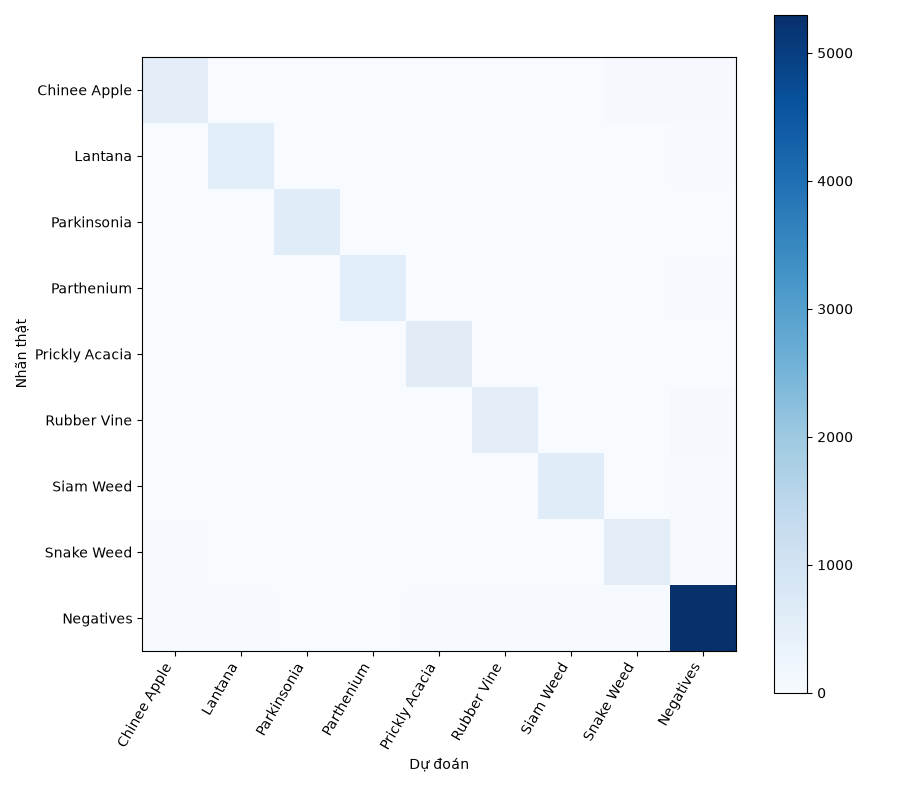

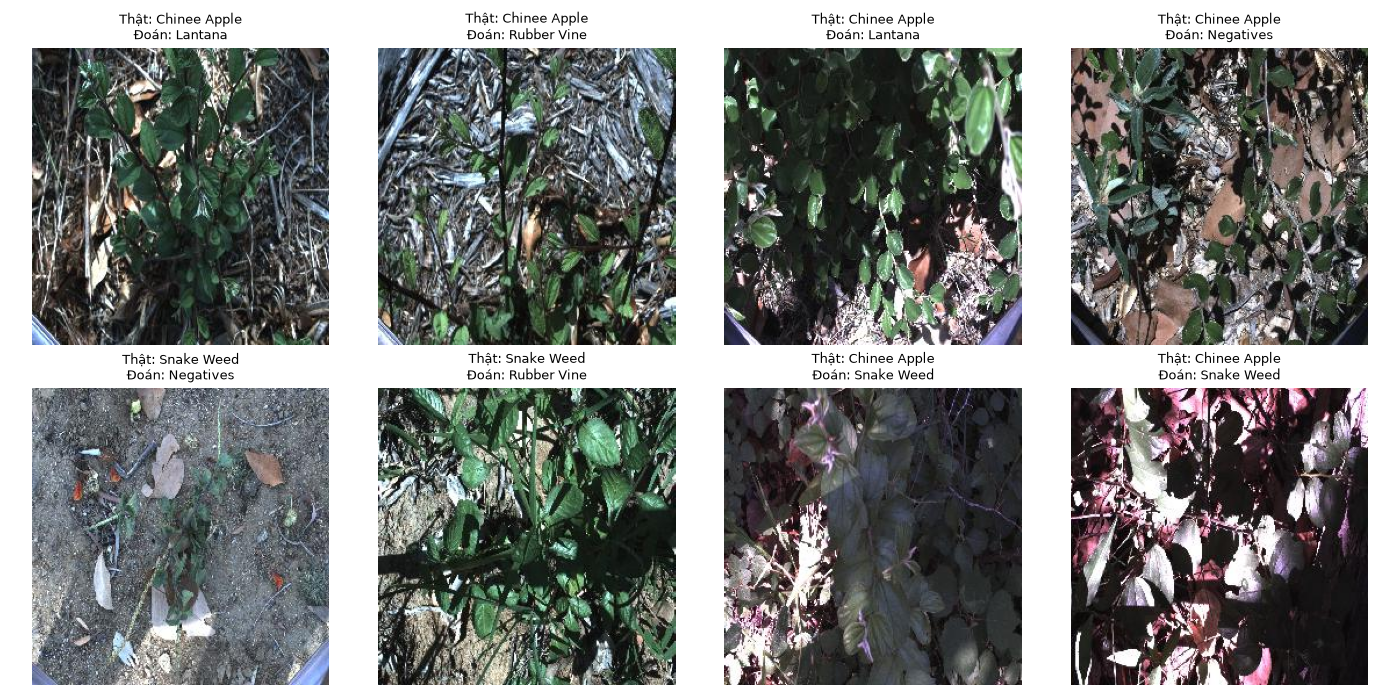

### Kết luận

Accuracy test **93,67% ±0,30 điểm phần trăm**; macro-F1 **0,9139 ±0,0044**. Δ so T00 = **+0,0035 < std0,0058**; chưa chứng minh cải thiện chắc chắn. Recall Chinee apple **79,2%**, Snake weed **88,9%**. Độ trễ F01 bổ sung p95 **26,68ms** trên GTX1650, chưa gồm decode/resize/H2D. Xem report.md để đọc đầy đủ phân tích và hạn chế.

In [11]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("products")
else:
    if PROFILE != "smoke":
        from eval import load_group
        group = load_group(str(lab.pred / "F01_seed*_test.csv"), str(lab.labels / "test_subset0.csv"), ref_what="test")
        cm = sum(metrics["confusion"] for metrics in group.metrics)
        fig, ax = plt.subplots(figsize=(9, 8))
        image = ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(9), dataset.CLASS_NAMES, rotation=60, ha="right")
        ax.set_yticks(range(9), dataset.CLASS_NAMES)
        ax.set_xlabel("Dự đoán"); ax.set_ylabel("Nhãn thật")
        fig.colorbar(image, ax=ax); plt.tight_layout()
        plt.savefig(lab.curves / "F01_confusion.png"); plt.show()
        errors = pd.read_csv(lab.pred / "F01_seed0_test.csv")
        errors = errors[errors.y_true != errors.y_pred]
        hard = errors[errors.y_true.isin([0, 7])]
        samples = pd.concat([hard, errors]).drop_duplicates("Filename").head(8)
        fig, axes = plt.subplots(2, 4, figsize=(14, 7))
        for ax in axes.ravel(): ax.axis("off")
        for (_, row), ax in zip(samples.iterrows(), axes.ravel()):
            with Image.open(lab.images / row.Filename) as im: ax.imshow(im.convert("RGB"))
            ax.set_title(f"Thật: {dataset.CLASS_NAMES[int(row.y_true)]}\nĐoán: {dataset.CLASS_NAMES[int(row.y_pred)]}", fontsize=9)
        plt.tight_layout(); plt.savefig(lab.curves / "F01_errors.png"); plt.show()
        archive = lab.products()
        print("Tổng thời gian (phút):", round((time.perf_counter() - STARTED) / 60, 1))
        print("Gói bài nộp:", archive)
        print("Đọc report.md và bổ sung kết luận, đánh đổi tốc độ/F1, giả thuyết lỗi trước khi nộp.")
    else:
        archive = lab.products()


## 10.1. Minh chứng bổ sung: lệch phân phối và Grad-CAM trên validation

**Kết quả lượt train local đã lưu — không train/test lại.**

Bonus sau nghiên cứu: validation sạch/tối/mờ/nhiễu, không train/refit T/test lại; Grad-CAM 6 lỗi validation.

,condition,n,seed,split,temperature,macro_f1,top1,ece_before,ece_after,nll
0,clean,3501,0,val,1.319943,0.918199,0.940588,0.020968,0.007613,0.197165
1,dark,3501,0,val,1.319943,0.816740,0.848615,0.059468,0.025972,0.461801
2,blur,3501,0,val,1.319943,0.610099,0.750643,0.170342,0.141027,0.986556
3,noise,3501,0,val,1.319943,0.876286,0.910883,0.036799,0.017521,0.268322


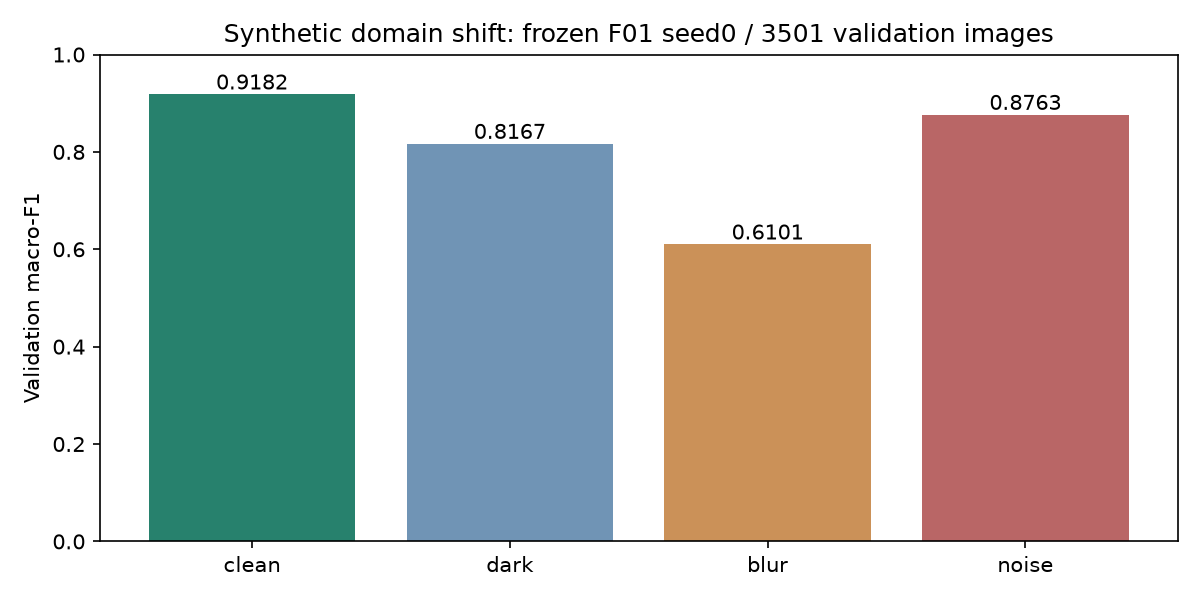

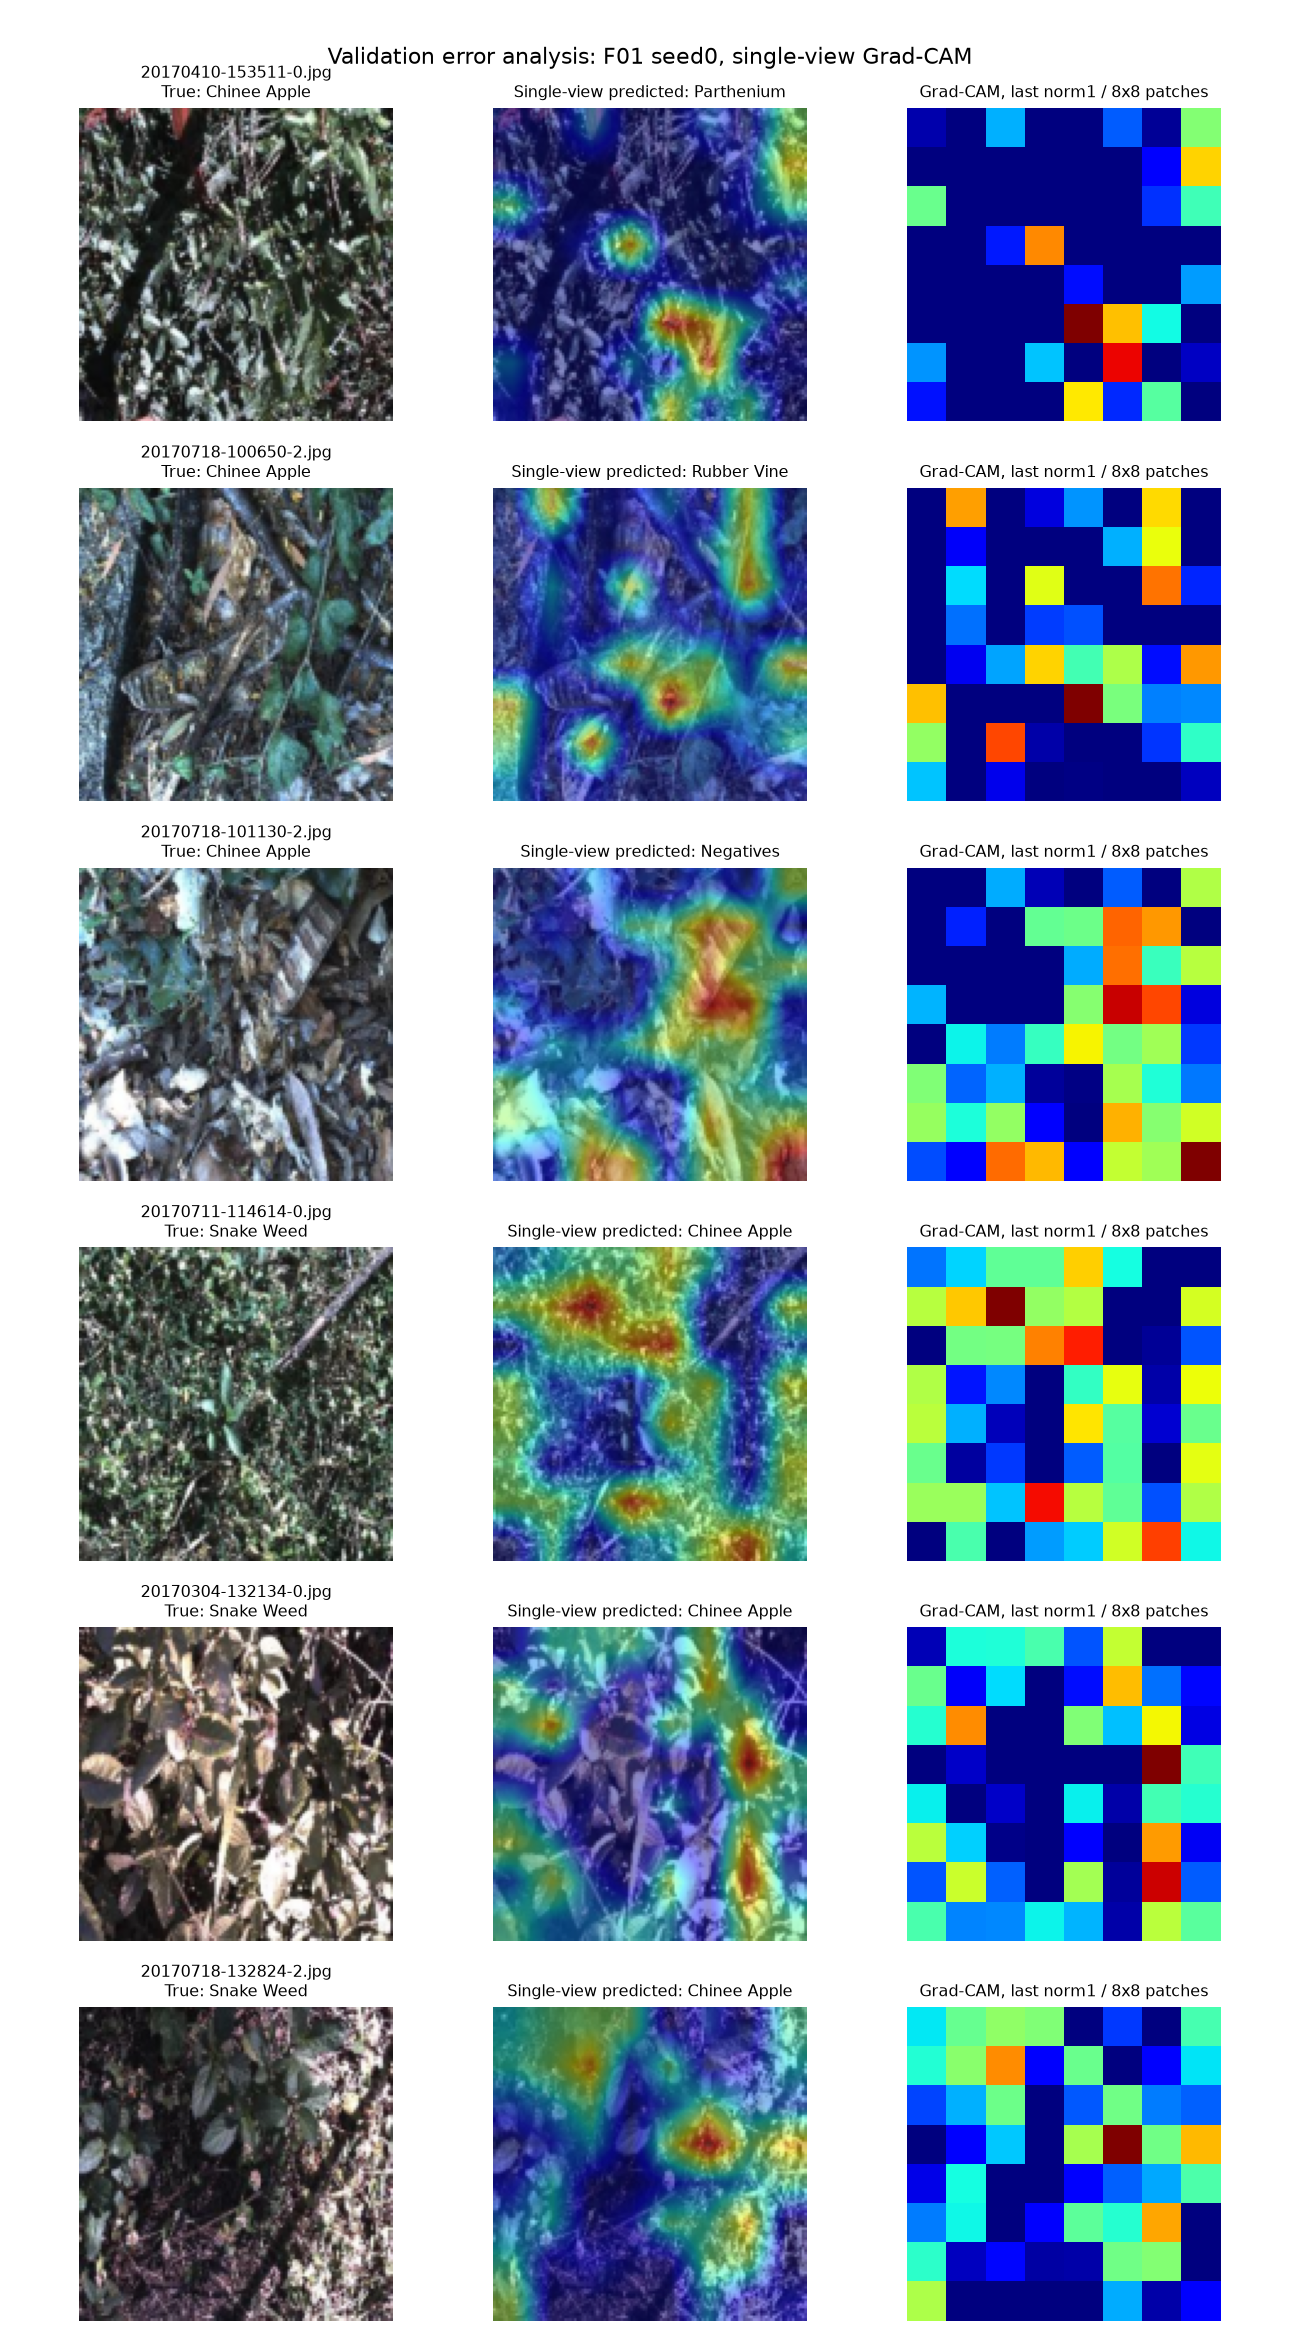

In [12]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("extras")
else:
    print("Bonus đã đo riêng trên validation của nghiên cứu gốc; xem report.md/code/submission_extras.py.")


## 11. Tải sản phẩm

Chế độ xem: tải notebook có output hoặc mở bài nộp trên GitHub. Chế độ train: tải ZIP mới sau Run all; checkpoint lưu Drive.

In [13]:
if globals().get("VIEW_SAVED_RESULTS", False):
    results.show("download")
else:
    if PROFILE != "smoke":
        from google.colab import files
        files.download(str(archive))


**Kết quả lượt train local đã lưu — không train/test lại.**

Notebook này đã có output sẵn để xem trên GitHub/Colab. Tải .ipynb bằng File → Download; bộ bài nộp đầy đủ nằm trong repository.

[Bài nộp đầy đủ](https://github.com/meth04/K4-DAY02-NguyenVanThan-02859/tree/main/submissions/02859_nguyen_van_than) · [Báo cáo](https://github.com/meth04/K4-DAY02-NguyenVanThan-02859/blob/main/submissions/02859_nguyen_van_than/report.md)